# Formerly: yield_plot.ipynb

## Define functions to load data

In [1]:
# ============================================================
# BLOCK 1 — Data loading helpers
# - Imports
# - Global config
# - Functions to read:
#     (i) LLDVE coefficient results (mTheta_hat, bootstrap draws)
#     (ii) Master CSV with climate/yield covariates
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1.1 Global config (can be edited)
# -------------------------------

# Folder where LLDVE results are stored
BASE_RESULTS_PATH = "thesis_results/results_LLDVE_OPT"

# Master CSV (your paper dataset)
MASTER_CSV_PATH = "master_panel_corn.csv"

# States / pooled codes you want to work with
STATES_TO_PLOT = ["17", "18", "19", "27", "31", "17_18_19_27"]  # IL, IN, IA, MN, WI?, pooled code

# LLDVE run identifiers
SEASON   = "GS"
MODEL_ID = "model_2"          # can switch to "model_3" etc.
RUN_NOTE = "logY_anomalyX"

# Base year guess for reconstructing calendar years from scaled index
BASE_YEAR_GUESS = 1951


# -------------------------------
# 1.2 LLDVE results: loading helpers
# -------------------------------

def _recover_years_from_index(idx, base_year=1951):
    """
    Recover calendar years from the index of mTheta_hat.

    If the index looks like a scaled time grid (e.g. 3..5 with ~73 points),
    reconstruct contiguous integer years starting at base_year.
    Otherwise, try to cast to int directly; if that fails, round.

    This matches the heuristic we used before.
    """
    vals = pd.Series(idx).astype(float).values
    vmin, vmax = float(vals.min()), float(vals.max())
    n = len(vals)

    # Heuristic: typical LLDVE time scaling yields something like [3,5]
    # (width ~2) with n equal to the number of annual observations.
    if (vmin >= 0.0) and (vmax <= 10.0) and (1.0 < (vmax - vmin) < 5.0):
        years = np.arange(base_year, base_year + n, dtype=int)
        return years

    # Otherwise assume these are actual years (or strings of years)
    try:
        years = pd.Index(idx).astype(int).values
        return years
    except Exception:
        # Last resort: round and cast
        years = np.rint(vals).astype(int)
        return years


def load_lldve_results(base_path,
                       states,
                       season="GS",
                       model_id="model_2",
                       run_note="logY_anomalyX",
                       base_year_guess=1951):
    """
    Load LLDVE outputs for each state (or pooled code) in `states`.

    Expects per run:
      - mTheta_hat.csv       : (T x p) with columns [gdd, kdd, precip, precip_sq, ...]
      - mTheta_stars_draws.npy : (B x T x p*) with last dim [intercept, gdd, kdd, precip, precip_sq, ...]

    Returns:
      results_data: dict[state_code] -> {
          'theta_hat'      : (T, p) array,
          'bootstrap_draws': (B, T, p*) array,
          'years'          : (T,) int array,
          'var_names'      : list of column names in mTheta_hat
      }
    """
    results_data = {}
    for state_code in states:
        run_label = f"{state_code}_{model_id}_{season}_{run_note}"
        results_dir = os.path.join(base_path, run_label)

        theta_path = os.path.join(results_dir, "mTheta_hat.csv")
        boot_path  = os.path.join(results_dir, "mTheta_stars_draws.npy")

        if not (os.path.exists(theta_path) and os.path.exists(boot_path)):
            print(f"[WARN] Missing files for state {state_code} at {results_dir}. Skipping.")
            continue

        theta_df = pd.read_csv(theta_path, index_col=0)

        # Recover years from index (handles scaled [3..5] case)
        years = _recover_years_from_index(theta_df.index, base_year=base_year_guess)

        var_names = list(theta_df.columns)
        theta_hat = theta_df.values              # (T, p)
        boots     = np.load(boot_path)           # (B, T, p*)

        # Align T dimension if needed (defensive)
        if boots.shape[1] != theta_hat.shape[0]:
            Tmin = min(boots.shape[1], theta_hat.shape[0])
            theta_hat = theta_hat[:Tmin, :]
            years     = years[:Tmin]
            boots     = boots[:, :Tmin, :]
            print(f"[ALIGN] Trimmed {state_code} to T={Tmin} years.")

        results_data[state_code] = {
            "theta_hat"      : theta_hat,
            "bootstrap_draws": boots,
            "years"          : years,
            "var_names"      : var_names,
        }

    return results_data


def process_loaded_data(results_dict):
    """
    Extract GDD/KDD coefficient paths and their bootstrap draws.

    Assumes:
      - mTheta_hat columns: [gdd, kdd, precip, precip_sq, ...]
      - bootstrap last dim: [intercept, gdd, kdd, precip, precip_sq, ...]

    Returns:
      proc[state_code] -> {
          'years'     : (T,),
          'gdd_coeffs': (T,),
          'kdd_coeffs': (T,),
          'gdd_draws' : (B, T),
          'kdd_draws' : (B, T)
      }
    """
    GDD_IDX_MAIN = 0
    KDD_IDX_MAIN = 1
    GDD_IDX_BOOT = 1
    KDD_IDX_BOOT = 2

    out = {}
    for st, d in results_dict.items():
        theta = d["theta_hat"]
        boots = d["bootstrap_draws"]

        out[st] = {
            "years"     : d["years"],
            "gdd_coeffs": theta[:, GDD_IDX_MAIN],
            "kdd_coeffs": theta[:, KDD_IDX_MAIN],
            "gdd_draws" : boots[:, :, GDD_IDX_BOOT],
            "kdd_draws" : boots[:, :, KDD_IDX_BOOT],
        }
    return out


# -------------------------------
# 1.3 Master CSV loading
# -------------------------------

def read_master_data(csv_path=MASTER_CSV_PATH):
    """
    Read the master CSV (paper dataset) with consistent dtypes.

    Ensures:
      - 'county', 'division_yield', 'division_noaa' are strings
      - 'state' is a zero-padded 2-digit string
    """
    dtype_dict = {
        "county"        : str,
        "division_yield": str,
        "division_noaa" : str,
        "state"         : str,
    }
    df = pd.read_csv(csv_path, dtype=dtype_dict)
    df["state"] = df["state"].str.zfill(2)
    return df


## Basic Helpers

In [3]:
# ============================================================
# BLOCK 2 — Degree-days, window averaging, and response curves
# ============================================================

# -------------------------------
# 2.1 Degree-day mapping
# -------------------------------

def degree_days_from_T(Tgrid, Tbase=10.0, Tthr=29.0):
    """
    Map a vector of daily max temperatures Tgrid (in °C) to:
      - GDD: degrees above Tbase up to Tthr
      - KDD: degrees above Tthr
    This is purely mechanical and does NOT depend on anomalies.
    """
    Tgrid = np.asarray(Tgrid, dtype=float)
    G = np.maximum(0.0, np.minimum(Tgrid, Tthr) - Tbase)  # beneficial warmth
    K = np.maximum(0.0, Tgrid - Tthr)                     # damaging heat
    return G, K


# -------------------------------
# 2.2 Averaging coefficients over a time window
# -------------------------------

def average_period_coeffs(state_block,
                          start_year,
                          end_year,
                          allow_partial=True,
                          min_years=1):
    """
    Average β_GDD(t) and β_KDD(t) over a calendar window [start_year, end_year].

    state_block: dict for a given state_code from proc_results, with keys:
        'years'      : (T,)
        'gdd_coeffs' : (T,)
        'kdd_coeffs' : (T,)
        'gdd_draws'  : (B, T)
        'kdd_draws'  : (B, T)

    Returns:
        bar_bGDD       : scalar (mean β_GDD over window)
        bar_bKDD       : scalar (mean β_KDD over window)
        bar_bGDD_draws : (B,) bootstrap means over window
        bar_bKDD_draws : (B,) bootstrap means over window
        (lo, hi)       : actual years used after clamping to data range
    """
    yrs = state_block["years"]
    ylo, yhi = int(yrs.min()), int(yrs.max())

    # Clamp requested window to available data
    lo = max(start_year, ylo)
    hi = min(end_year,   yhi)

    if not allow_partial and (start_year < ylo or end_year > yhi):
        raise ValueError(f"Window {start_year}-{end_year} outside data {ylo}-{yhi}.")
    if lo > hi:
        raise ValueError(f"No overlap for window {start_year}-{end_year} within data {ylo}-{yhi}.")

    mask = (yrs >= lo) & (yrs <= hi)
    if mask.sum() < min_years:
        raise ValueError(
            f"Insufficient years ({mask.sum()}) for {start_year}-{end_year} "
            f"(clamped to {lo}-{hi})."
        )

    g = state_block["gdd_coeffs"][mask]
    k = state_block["kdd_coeffs"][mask]

    bar_bGDD = np.mean(g)
    bar_bKDD = np.mean(k)

    # Bootstrap means over the same window
    g_draws = state_block["gdd_draws"][:, mask]   # (B, n_win)
    k_draws = state_block["kdd_draws"][:, mask]   # (B, n_win)

    bar_bGDD_draws = np.mean(g_draws, axis=1)     # (B,)
    bar_bKDD_draws = np.mean(k_draws, axis=1)     # (B,)

    return bar_bGDD, bar_bKDD, bar_bGDD_draws, bar_bKDD_draws, (lo, hi)


# -------------------------------
# 2.3 Temperature–response curve on a T grid
# -------------------------------

def temp_response_curve(bar_bGDD,
                        bar_bKDD,
                        Tgrid,
                        Tref=20.0,
                        boot_bGDD=None,
                        boot_bKDD=None,
                        recenter=True,
                        scale="percent"):
    """
    Construct a yield–temperature curve from window-averaged coefficients.

    Inputs:
      bar_bGDD, bar_bKDD : scalars (epoch-averaged β_GDD, β_KDD)
      Tgrid               : array of temperatures (°C), e.g. np.linspace(10,40,601)
      Tref                : reference temperature (°C) for recentering
      boot_bGDD, boot_bKDD: (B,) bootstrap means, or None to skip CIs
      recenter            : if True, plot Δlog y(T) relative to Tref
      scale               : "percent" for % yield impact, "log" for Δlog y

    Returns:
      y_main : effect curve (same length as Tgrid)
      ci_lo  : lower CI (or None)
      ci_hi  : upper CI (or None)
    """
    Tgrid = np.asarray(Tgrid, dtype=float)

    # ---- Deterministic path in log-yield ----
    G, K = degree_days_from_T(Tgrid)
    dlog = bar_bGDD * G + bar_bKDD * K      # Δ log y as function of T

    if recenter:
        Gref, Kref = degree_days_from_T(np.array([Tref]))
        dlog_ref = (bar_bGDD * Gref + bar_bKDD * Kref)[0]
        dlog_main = dlog - dlog_ref         # effect relative to Tref
    else:
        dlog_main = dlog

    # ---- Convert scale ----
    if scale == "percent":
        y_main = 100.0 * (np.exp(dlog_main) - 1.0)
    elif scale == "log":
        y_main = dlog_main
    else:
        raise ValueError("scale must be 'percent' or 'log'")

    # ---- Bootstrap CI (optional) ----
    ci_lo = ci_hi = None
    if (boot_bGDD is not None) and (boot_bKDD is not None):
        B = len(boot_bGDD)
        Gmat = G[None, :]                    # (1, nT)
        Kmat = K[None, :]                    # (1, nT)
        BG   = boot_bGDD[:, None]           # (B, 1)
        BK   = boot_bKDD[:, None]           # (B, 1)

        dlog_boot = BG * Gmat + BK * Kmat   # (B, nT)
        if recenter:
            Gref, Kref = degree_days_from_T(np.array([Tref]))
            dlog_ref_boot = (boot_bGDD * Gref + boot_bKDD * Kref)[:, 0]  # (B,)
            dlog_boot = dlog_boot - dlog_ref_boot[:, None]

        if scale == "percent":
            y_boot = 100.0 * (np.exp(dlog_boot) - 1.0)
        else:
            y_boot = dlog_boot

        ci_lo = np.percentile(y_boot,  2.5, axis=0)
        ci_hi = np.percentile(y_boot, 97.5, axis=0)

    return y_main, ci_lo, ci_hi


# -------------------------------
# 2.4 Window builders
# -------------------------------

def make_decades_from_years(yrs, width=10):
    """
    Simple decade-style windows of fixed width (default 10 years).

    yrs  : array-like of years (int)
    width: window length in years (10 gives 1951–1960, 1961–1970, etc.)

    Returns: list of (start_year, end_year) windows.
    """
    yrs = np.asarray(yrs, dtype=int)
    ylo, yhi = int(yrs.min()), int(yrs.max())
    start = (ylo // width) * width
    windows = []
    y = start
    while y + width - 1 <= yhi:
        if y + width - 1 >= ylo:
            windows.append((y, y + width - 1))
        y += width
    return windows


def make_fixed_windows(years,
                       width=8,
                       align="start",
                       drop="auto",
                       drop_edges=False):
    """
    Build consecutive, non-overlapping windows of given width.

    Parameters
    ----------
    years : array-like
        Calendar years present in the data.
    width : int
        Window length in years (e.g., 8 or 10).
    align : {"start","end"}
        "start": anchor at earliest year; "end": anchor at latest year.
    drop : {"none","auto", int}
        "none" : never trim; only include full windows that fit.
        "auto" : trim the minimal number of years from one edge so that
                 the total span becomes a multiple of `width`.
        int    : explicitly drop this many years from the end (use negative
                 to drop from the start).
    drop_edges : bool
        If True, drop the very first and very last year before building windows.

    Returns
    -------
    windows : list of (start_year, end_year)
    """
    yrs = np.sort(np.unique(np.asarray(years, dtype=int)))
    if yrs.size == 0:
        return []

    if drop_edges and yrs.size >= 3:
        yrs = yrs[1:-1]

    ylo, yhi = int(yrs.min()), int(yrs.max())
    span = yhi - ylo + 1

    trim_start = 0
    trim_end   = 0

    if isinstance(drop, int):
        if drop >= 0:
            trim_end = drop
        else:
            trim_start = -drop
    elif drop == "auto":
        r = span % width
        if r != 0:
            if align == "start":
                trim_end = r
            elif align == "end":
                trim_start = r
            else:
                trim_start = r // 2
                trim_end   = r - trim_start
    elif drop == "none":
        pass
    else:
        raise ValueError("drop must be 'none', 'auto', or an int (±).")

    ylo2 = ylo + trim_start
    yhi2 = yhi - trim_end
    if yhi2 < ylo2:
        return []

    windows = []
    if align == "end":
        start = yhi2 - width + 1
        while start >= ylo2:
            windows.append((start, start + width - 1))
            start -= width
        windows = windows[::-1]
    else:
        start = ylo2
        while start + width - 1 <= yhi2:
            windows.append((start, start + width - 1))
            start += width

    return windows


def make_epoch_windows(years, epochs=((1951, 1975), (1976, 2000), (2001, 2023))):
    """
    Return user-defined epoch windows as a list of (start, end) tuples.

    - years  : array-like (not used except for sanity; clamping happens later)
    - epochs : iterable of (start_year, end_year), e.g.
               ((1951,1975), (1976,2000), (2001,2023))

    The actual clamping to data availability is handled in average_period_coeffs.
    """
    _ = np.asarray(years)  # just to be sure something is passed
    return [(int(a), int(b)) for (a, b) in epochs]


# -------------------------------
# 2.5 Generic plotting for a set of windows
# -------------------------------

def plot_window_curves_for_state(state_code,
                                 state_block,
                                 windows,
                                 Tgrid,
                                 Tref,
                                 title_prefix="State",
                                 recenter=True,
                                 show_ci=False,
                                 scale="percent",
                                 show_actual_in_legend=True):
    """
    Generic plotting wrapper: for a given state (or pooled code) and a list
    of windows [(start,end), ...], plot the temperature–yield curves.

    This generalizes decade / fixed / epoch plots.

    Parameters
    ----------
    state_code  : str
        State or pooled identifier (for title).
    state_block : dict
        Entry from proc_results[state_code].
    windows     : list of (start_year, end_year)
    Tgrid       : array of temperatures to evaluate (°C).
    Tref        : reference temperature for recentering.
    title_prefix: e.g. "State" or "Pooled".
    recenter    : bool, whether to recenter at Tref.
    show_ci     : bool, whether to draw bootstrap CI bands.
    scale       : "percent" or "log".
    show_actual_in_legend : bool, show clamped years if they differ from request.

    Returns
    -------
    ax : matplotlib Axes
    """
    plt.figure(figsize=(7.0, 5.0))
    any_plotted = False

    for (y0_req, y1_req) in windows:
        try:
            bar_g, bar_k, boot_g, boot_k, (lo, hi) = average_period_coeffs(
                state_block,
                y0_req,
                y1_req,
                allow_partial=True,
                min_years=1
            )
        except ValueError:
            print(f"[{state_code}] Skipping {y0_req}-{y1_req}: no overlap.")
            continue

        curve, lo_ci, hi_ci = temp_response_curve(
            bar_g,
            bar_k,
            Tgrid,
            Tref=Tref,
            boot_bGDD=(boot_g if show_ci else None),
            boot_bKDD=(boot_k if show_ci else None),
            recenter=recenter,
            scale=scale,
        )

        if show_actual_in_legend and ((lo != y0_req) or (hi != y1_req)):
            label = f"{y0_req}–{y1_req} (used {lo}–{hi})"
        else:
            label = f"{y0_req}–{y1_req}"

        plt.plot(Tgrid, curve, label=label)
        if show_ci and (lo_ci is not None):
            plt.fill_between(Tgrid, lo_ci, hi_ci, alpha=0.2)

        any_plotted = True

    # Visual guides
    plt.axvline(29, linestyle="--", linewidth=1)
    if recenter:
        plt.axhline(0, linestyle=":", linewidth=1)

    ylabel = "effect on yield (Δ log units)" if scale == "log" else "effect on yield (%)"
    if recenter:
        ylabel += f" (relative to {Tref}°C day)"

    plt.xlabel("Daily max temperature (°C)")
    plt.ylabel(ylabel)
    plt.title(f"{title_prefix} {state_code}: Temperature–Yield Response")
    if any_plotted:
        plt.legend()
    else:
        plt.legend([f"No overlapping windows for {state_code}"])
    plt.tight_layout()
    return plt.gca()


## Define Tref

In [5]:
# ============================================================
# BLOCK 3 — Choosing T_ref, climatology range, window scheme,
#            and producing the yield–temperature plots
# ============================================================

# -------------------------------
# 3.1 Find TMAX column and compute climatological T_ref
# -------------------------------

def find_tmax_column(df):
    """
    Try to identify the growing-season average max temperature column.
    Adjust candidates if your naming differs.
    """
    candidates = [
        "TMAX_AVG_GS",
        "tmax_avg_gs",
        "TMAX_GS_AVG",
        "tmax_gs_avg",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of the TMAX candidates found in columns: {candidates}")


def compute_climatological_tref(df,
                                tmax_col=None,
                                mode="pooled",
                                states=None,
                                clim_year_min=1951,
                                clim_year_max=2023):
    """
    Compute climatological reference temperature(s) from the master CSV.

    Parameters
    ----------
    df           : master DataFrame
    tmax_col     : column with GS mean daily max temperature
    mode         : 'pooled', 'state', or 'county'
    states       : optional list of 2-digit state codes to restrict the sample
    clim_year_min, clim_year_max : year bounds for the climatological period

    Returns
    -------
    mode == 'pooled' -> scalar float
    mode == 'state'  -> dict: state_code -> float
    mode == 'county' -> DataFrame with ['state','county','Tref_clim']
    """
    if tmax_col is None:
        tmax_col = find_tmax_column(df)

    df_sub = df.copy()

    # Restrict to climatology window
    df_sub = df_sub[(df_sub["year"] >= clim_year_min) & (df_sub["year"] <= clim_year_max)]

    # Restrict to selected states if requested
    if states is not None:
        states = [str(s).zfill(2) for s in states]
        df_sub = df_sub[df_sub["state"].isin(states)]

    # Drop missing TMAX
    df_sub = df_sub[np.isfinite(df_sub[tmax_col])]

    if df_sub.empty:
        raise ValueError("No data left after applying climatology filters to compute T_ref.")

    if mode == "pooled":
        return float(df_sub[tmax_col].mean())

    elif mode == "state":
        # Returns dict state -> Tref
        s_means = df_sub.groupby("state")[tmax_col].mean()
        return {st: float(val) for st, val in s_means.items()}

    elif mode == "county":
        # Returns a DataFrame with per-(state,county) climatological reference
        c_means = (
            df_sub.groupby(["state", "county"])[tmax_col]
                  .mean()
                  .reset_index()
                  .rename(columns={tmax_col: "Tref_clim"})
        )
        return c_means

    else:
        raise ValueError("mode must be 'pooled', 'state', or 'county'.")



## load LLDVE results + master CSV

In [7]:
# ==============================
# CELL 1 — Load data
# ==============================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths & basic config ---
BASE_RESULTS_PATH = "thesis_results/results_LLDVE_OPT"
MASTER_CSV_PATH   = "master_panel_corn.csv"

SEASON   = "GS"
MODEL_ID = "model_3"          # you had model_3 in your last snippet
RUN_NOTE = "logY_anomalyX"

# States to include in LLDVE plots
STATES_TO_PLOT = ["17", "18", "19", "27", "31", "17_18_19_27"]  # IL, IN, IA, MN, WI?, pooled

# --- Load LLDVE results for all states of interest ---
raw_results = load_lldve_results(
    base_path=BASE_RESULTS_PATH,
    states=STATES_TO_PLOT,
    season=SEASON,
    model_id=MODEL_ID,
    run_note=RUN_NOTE,
    base_year_guess=1951
)

proc_results = process_loaded_data(raw_results)

# Quick sanity check on year ranges
for st, block in proc_results.items():
    yrs = block["years"]
    print(f"State {st}: years {yrs.min()}–{yrs.max()} (n={len(yrs)})")

# --- Load master CSV (for climatology & anomalies etc.) ---
df_master = pd.read_csv(MASTER_CSV_PATH)

# Make sure state is 2-digit string
df_master["state"] = df_master["state"].astype(str).str.zfill(2)

print(
    f"Master CSV loaded: shape={df_master.shape}, "
    f"years {int(df_master['year'].min())}–{int(df_master['year'].max())}"
)


[ALIGN] Trimmed 17 to T=73 years.
[ALIGN] Trimmed 18 to T=73 years.
[ALIGN] Trimmed 19 to T=73 years.
[ALIGN] Trimmed 27 to T=73 years.
[ALIGN] Trimmed 31 to T=73 years.
[ALIGN] Trimmed 17_18_19_27 to T=73 years.
State 17: years 1951–2023 (n=73)
State 18: years 1951–2023 (n=73)
State 19: years 1951–2023 (n=73)
State 27: years 1951–2023 (n=73)
State 31: years 1951–2023 (n=73)
State 17_18_19_27: years 1951–2023 (n=73)
Master CSV loaded: shape=(55814, 93), years 1929–2024


## Run the Temp-Yield Plots

In [9]:
# ==============================
# CELL 2 — Common settings + T_ref
# ==============================

# 2.1 Plot settings
TGRID    = np.linspace(10.0, 40.0, 601)
RECENTER = True
SHOW_CI  = False          # you can flip to True later
SCALE    = "log"          # or "percent"

# 2.2 Climatology range
CLIM_YR_MIN, CLIM_YR_MAX = 1951, 2023

# 2.3 T_ref mode
#   "manual"      : fixed value (TREF_MANUAL)
#   "pooled_clim" : pooled GS Tmax over selected states, 1951–2023
#   "state_clim"  : state-specific GS Tmax (pooled curve uses their mean)
TREF_MODE   = "pooled_clim"    # <-- base setting we discussed
TREF_MANUAL = 22.0             # used only if TREF_MODE == "manual"

# States used for climatology
STATES_FOR_CLIM = ["17", "18", "19", "27", "31"]

# 2.4 Compute T_ref(s)
tmax_col = find_tmax_column(df_master)
print(f"Using TMAX column: {tmax_col}")

Tref_global  = None
Tref_by_state = None

if TREF_MODE == "manual":
    Tref_global = TREF_MANUAL
    print(f"[TREF] Manual reference temperature: {Tref_global:.2f} °C")

elif TREF_MODE == "pooled_clim":
    Tref_global = compute_climatological_tref(
        df_master,
        tmax_col=tmax_col,
        mode="pooled",
        states=STATES_FOR_CLIM,
        clim_year_min=CLIM_YR_MIN,
        clim_year_max=CLIM_YR_MAX,
    )
    print(
        f"[TREF] Pooled climatological GS Tmax over states {STATES_FOR_CLIM}, "
        f"{CLIM_YR_MIN}–{CLIM_YR_MAX}: {Tref_global:.2f} °C"
    )

elif TREF_MODE == "state_clim":
    Tref_by_state = compute_climatological_tref(
        df_master,
        tmax_col=tmax_col,
        mode="state",
        states=STATES_FOR_CLIM,
        clim_year_min=CLIM_YR_MIN,
        clim_year_max=CLIM_YR_MAX,
    )
    Tref_global = float(np.mean(list(Tref_by_state.values())))
    print("[TREF] State-specific climatological T_ref (°C):")
    for s, v in Tref_by_state.items():
        print(f"   state {s}: {v:.2f}")
    print(f"[TREF] Global fallback (mean across states): {Tref_global:.2f} °C")

else:
    raise ValueError("TREF_MODE must be 'manual', 'pooled_clim', or 'state_clim'.")

# Common reference years (assume all have same span)
ref_state = next(iter(proc_results.keys()))
years_ref = proc_results[ref_state]["years"]
print(f"[YEARS] Reference years span: {years_ref.min()}–{years_ref.max()} (n={len(years_ref)})")


Using TMAX column: TMAX_AVG_GS
[TREF] Pooled climatological GS Tmax over states ['17', '18', '19', '27', '31'], 1951–2023: 24.68 °C
[YEARS] Reference years span: 1951–2023 (n=73)


### decade (10-year) plots

[WINDOWS] Decades: [(1950, 1959), (1960, 1969), (1970, 1979), (1980, 1989), (1990, 1999), (2000, 2009), (2010, 2019)]
[PLOT-DECADES] State 17: T_ref=24.68 °C


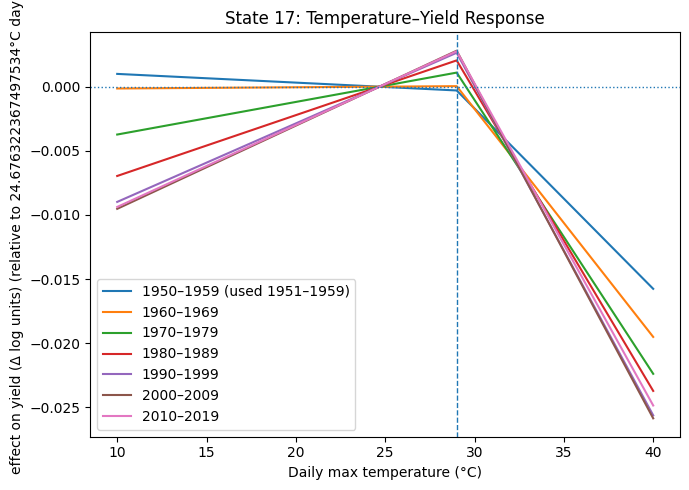

[PLOT-DECADES] State 18: T_ref=24.68 °C


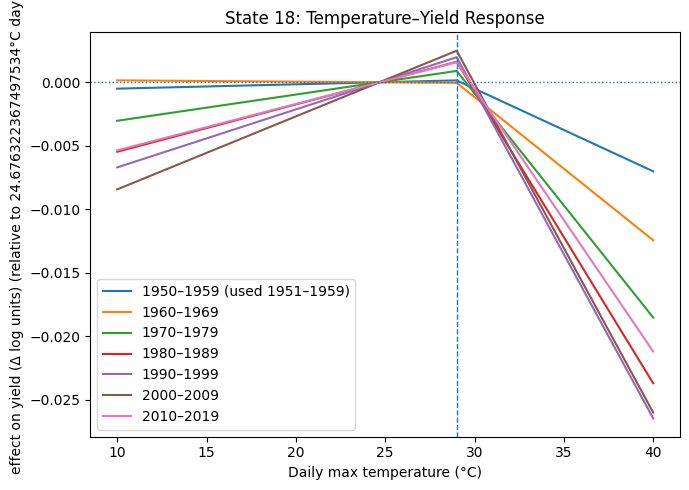

[PLOT-DECADES] State 19: T_ref=24.68 °C


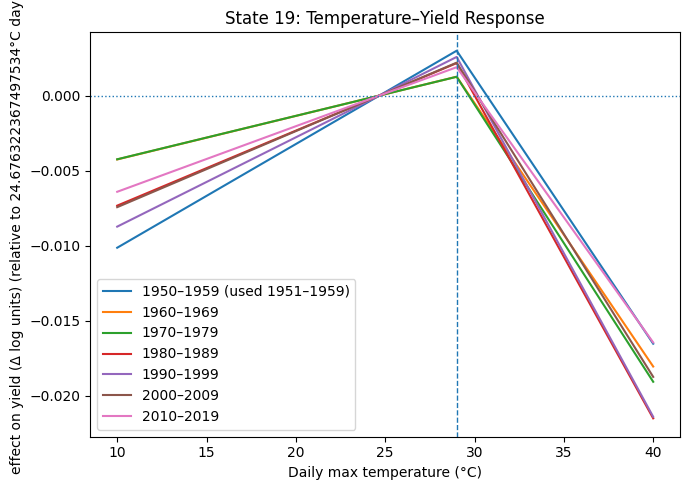

[PLOT-DECADES] State 27: T_ref=24.68 °C


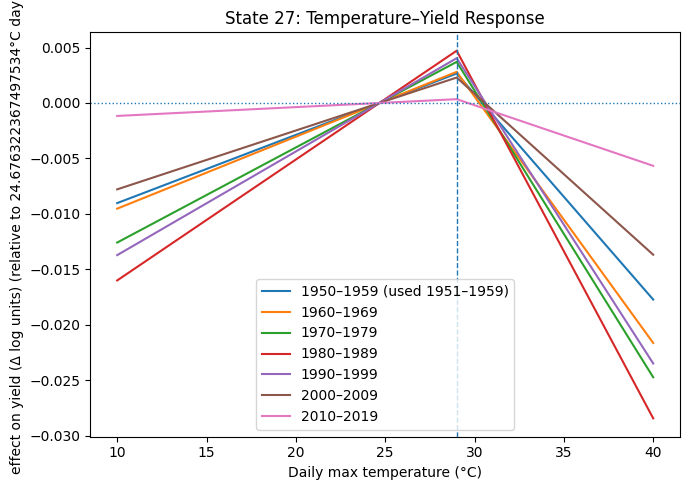

[PLOT-DECADES] State 31: T_ref=24.68 °C


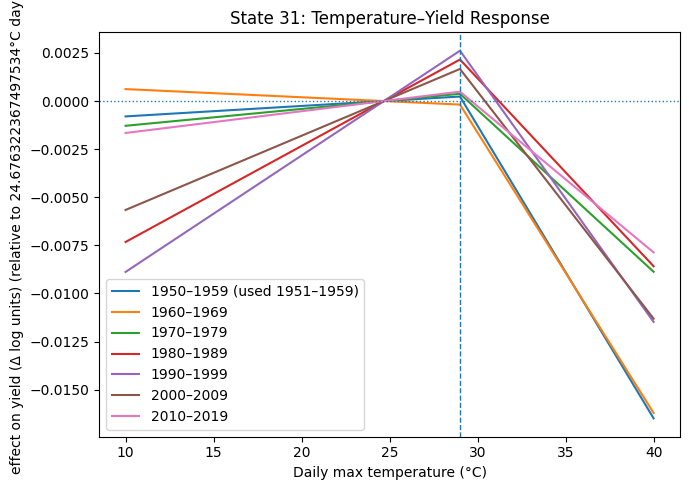

[PLOT-DECADES] State 17_18_19_27: T_ref=24.68 °C


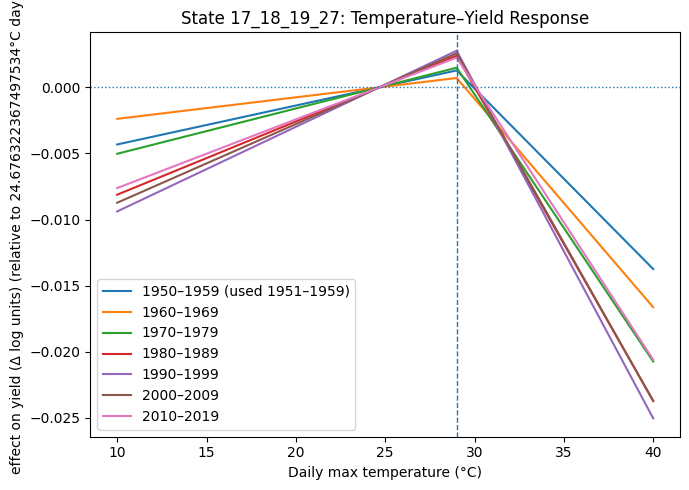

In [11]:
# ==============================
# CELL 3 — Decade plots (10-year windows)
# ==============================

# Build 10-year windows (e.g. 1951–60, 61–70, ...)
decade_windows = make_decades_from_years(years_ref, width=10)
print(f"[WINDOWS] Decades: {decade_windows}")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping decades.")
        continue

    # Decide T_ref for this state
    if (Tref_by_state is not None) and (st in Tref_by_state):
        tref_use = Tref_by_state[st]
    else:
        tref_use = Tref_global

    print(f"[PLOT-DECADES] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=decade_windows,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


### 7-year-step plots

[WINDOWS] 7-year blocks: [(1951, 1957), (1958, 1964), (1965, 1971), (1972, 1978), (1979, 1985), (1986, 1992), (1993, 1999), (2000, 2006), (2007, 2013), (2014, 2020)]
[PLOT-7YR] State 17: T_ref=24.68 °C


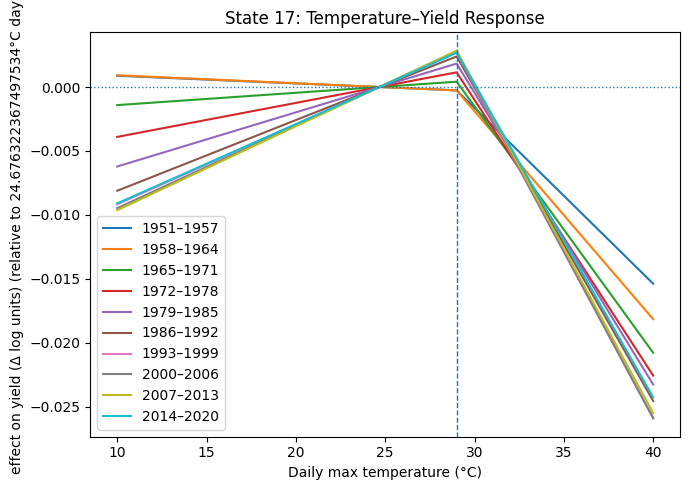

[PLOT-7YR] State 18: T_ref=24.68 °C


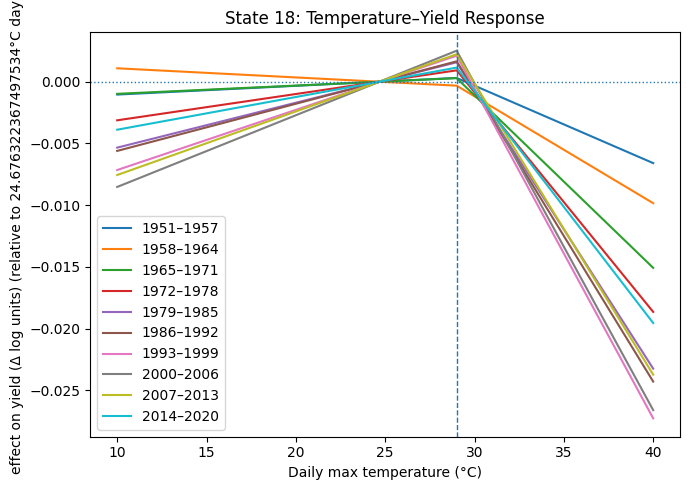

[PLOT-7YR] State 19: T_ref=24.68 °C


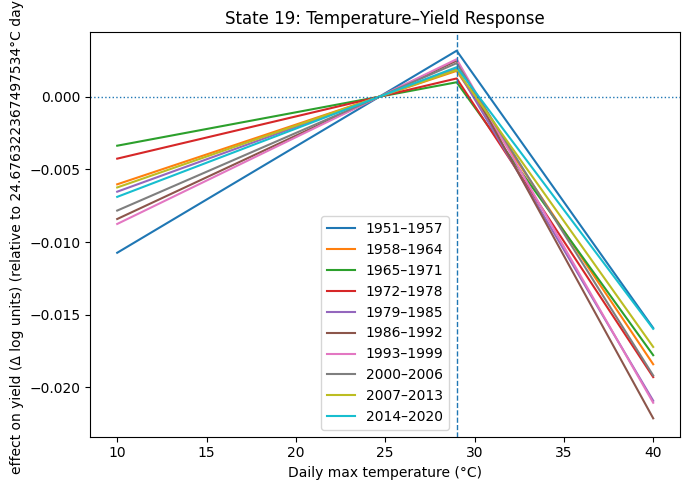

[PLOT-7YR] State 27: T_ref=24.68 °C


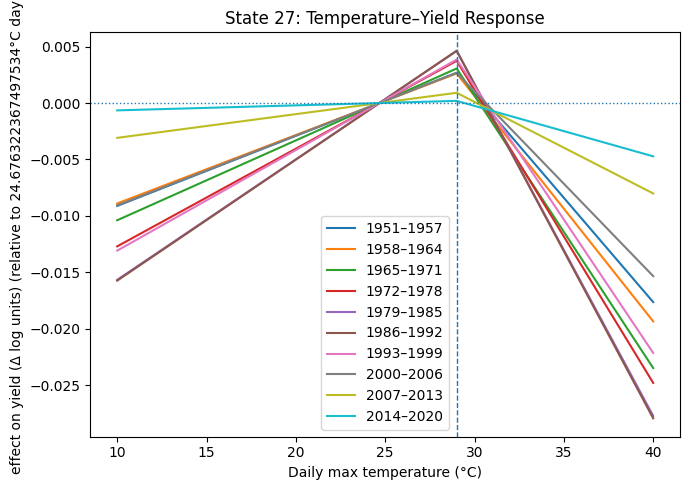

[PLOT-7YR] State 31: T_ref=24.68 °C


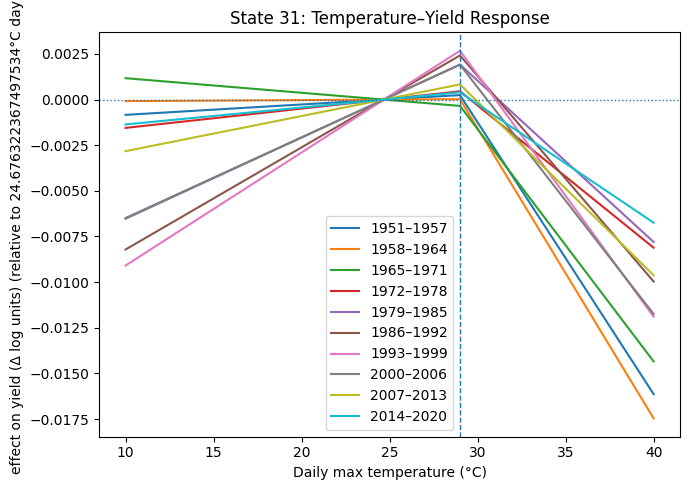

[PLOT-7YR] State 17_18_19_27: T_ref=24.68 °C


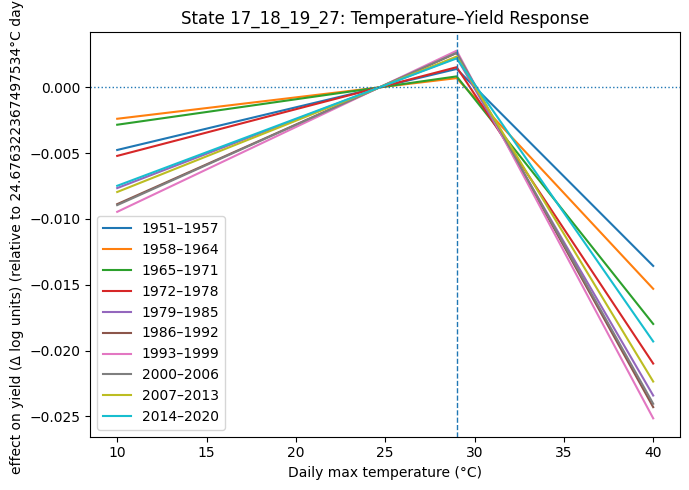

In [13]:
# ==============================
# CELL 4 — 7-year windows (non-overlapping)
# ==============================

windows7 = make_fixed_windows(
    years_ref,
    width=7,
    align="start",      # anchor at earliest year
    drop="auto",        # auto-trim tail to multiple of 7
    drop_edges=False
)

print(f"[WINDOWS] 7-year blocks: {windows7}")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping 7-year blocks.")
        continue

    if (Tref_by_state is not None) and (st in Tref_by_state):
        tref_use = Tref_by_state[st]
    else:
        tref_use = Tref_global

    print(f"[PLOT-7YR] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=windows7,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


### 3-epoch plots (1951–75 / 76–00 / 01–23)

[WINDOWS] 3 epochs: [(1951, 1975), (1976, 2000), (2001, 2023)]
[PLOT-EPOCH] State 17: T_ref=24.68 °C


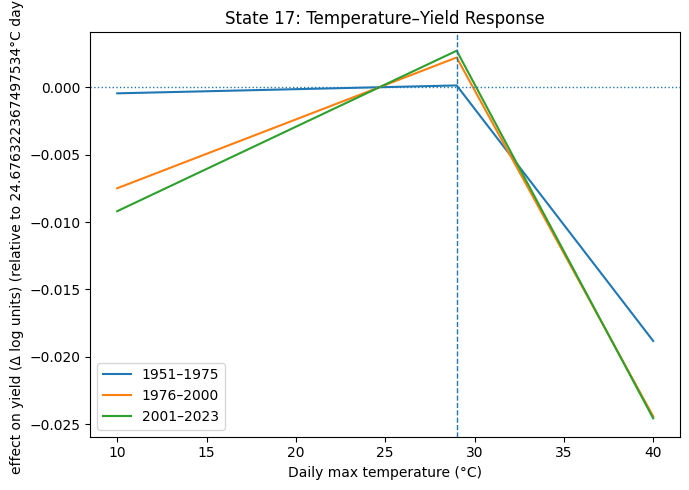

[PLOT-EPOCH] State 18: T_ref=24.68 °C


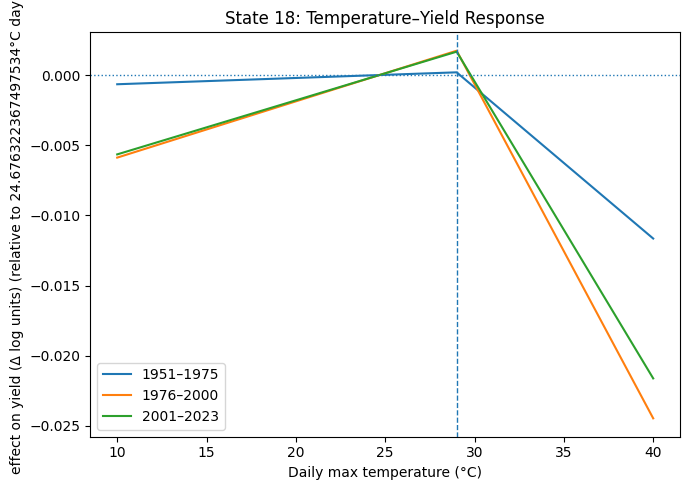

[PLOT-EPOCH] State 19: T_ref=24.68 °C


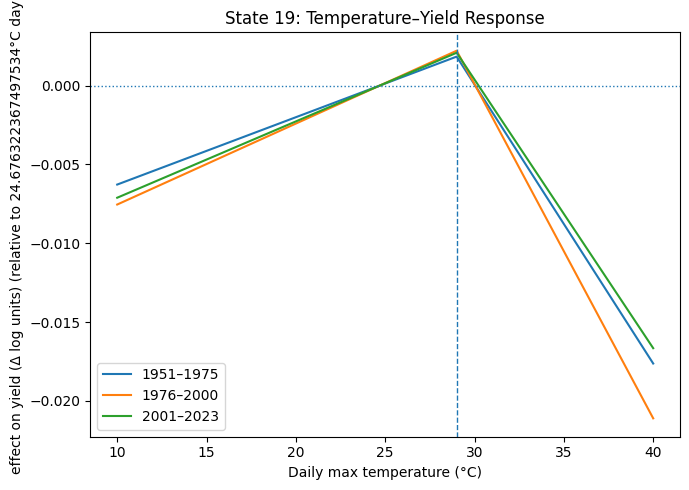

[PLOT-EPOCH] State 27: T_ref=24.68 °C


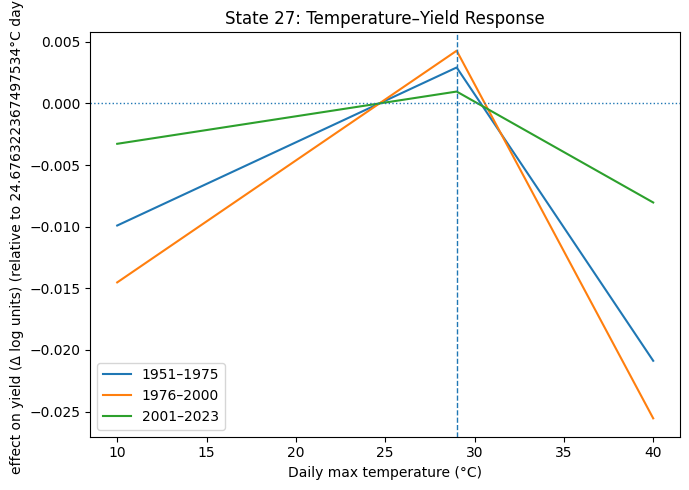

[PLOT-EPOCH] State 31: T_ref=24.68 °C


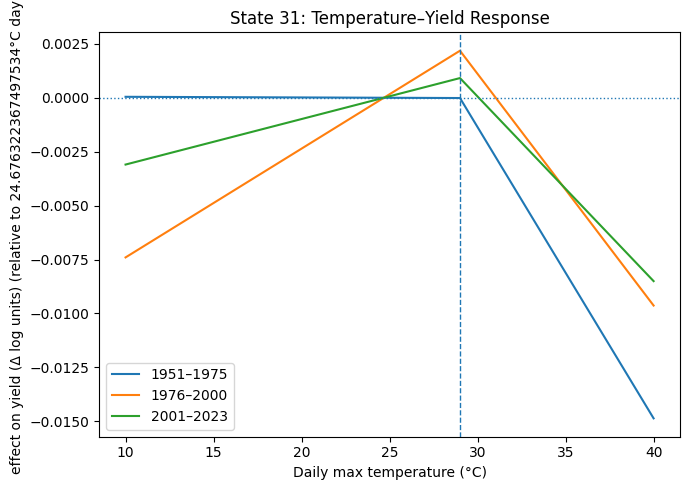

[PLOT-EPOCH] State 17_18_19_27: T_ref=24.68 °C


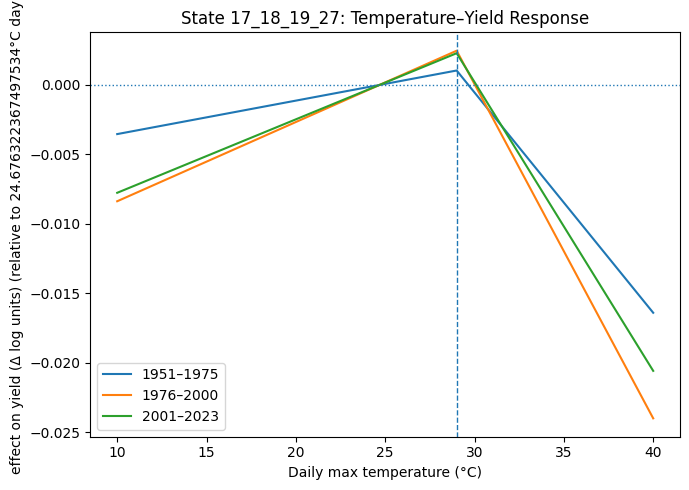

In [15]:
# ==============================
# CELL 5 — 3-epoch plots
# ==============================

EPOCHS_3 = (
    (1951, 1975),
    (1976, 2000),
    (2001, 2023),
)

epoch_windows = make_epoch_windows(years_ref, epochs=EPOCHS_3)
print(f"[WINDOWS] 3 epochs: {epoch_windows}")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping epochs.")
        continue

    if (Tref_by_state is not None) and (st in Tref_by_state):
        tref_use = Tref_by_state[st]
    else:
        tref_use = Tref_global

    print(f"[PLOT-EPOCH] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=epoch_windows,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


## Other Tref options for Epoch

#### Epoch plots with manual Tref

[WINDOWS-MANUAL] 3 epochs: [(1951, 1975), (1976, 2000), (2001, 2023)]
[TREF-MANUAL] Using fixed T_ref = 22.00 °C for all states.
[PLOT-EPOCH-MANUAL] State 17: T_ref=22.00 °C


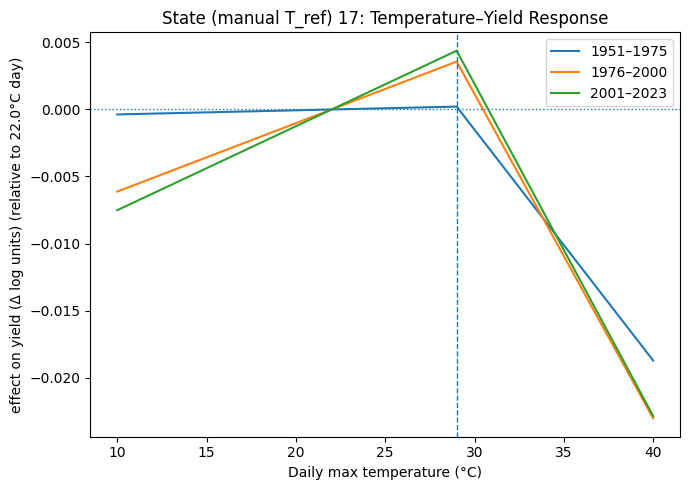

[PLOT-EPOCH-MANUAL] State 18: T_ref=22.00 °C


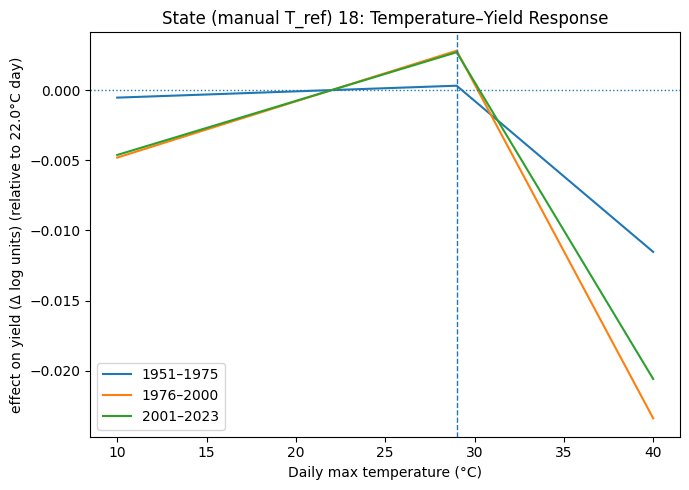

[PLOT-EPOCH-MANUAL] State 19: T_ref=22.00 °C


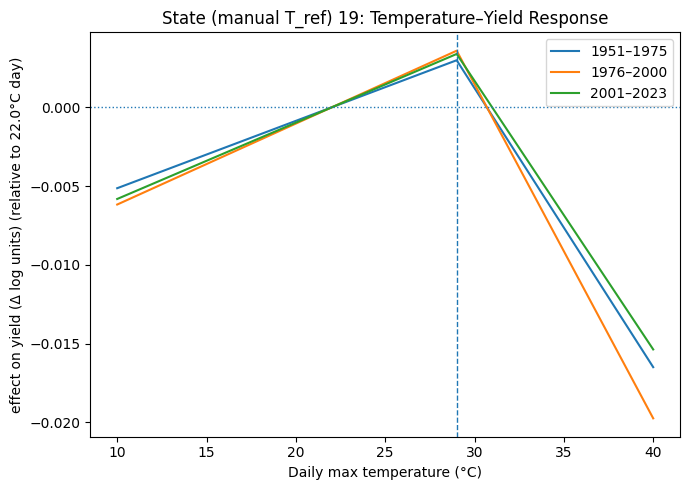

[PLOT-EPOCH-MANUAL] State 27: T_ref=22.00 °C


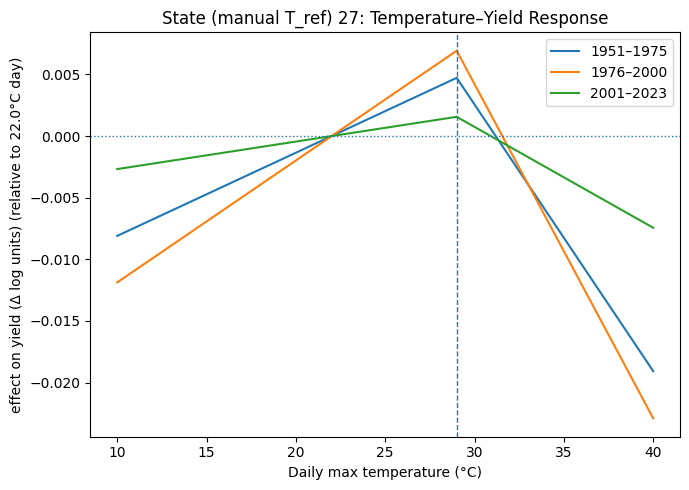

[PLOT-EPOCH-MANUAL] State 31: T_ref=22.00 °C


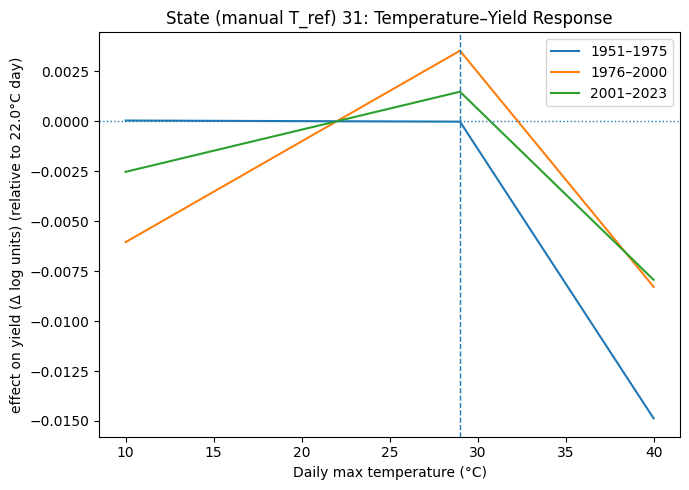

[PLOT-EPOCH-MANUAL] State 17_18_19_27: T_ref=22.00 °C


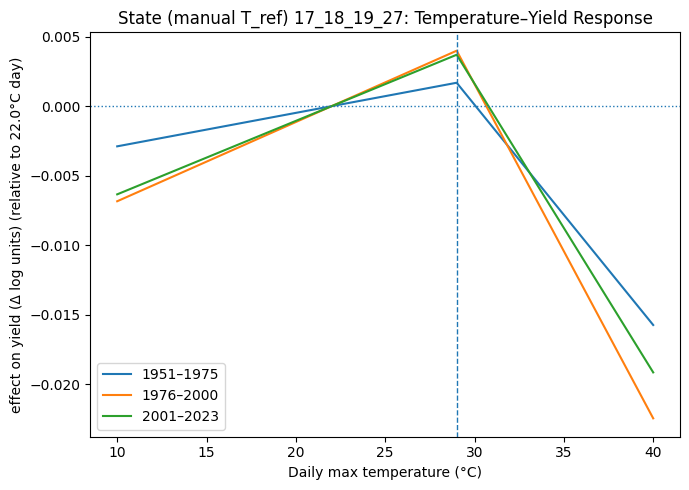

In [18]:
# ==============================
# CELL 6A — Epoch plots, manual T_ref
# ==============================

# 3 epochs (same as before)
EPOCHS_3 = (
    (1951, 1975),
    (1976, 2000),
    (2001, 2023),
)

# Reference years
ref_state = next(iter(proc_results.keys()))
years_ref = proc_results[ref_state]["years"]
epoch_windows = make_epoch_windows(years_ref, epochs=EPOCHS_3)
print(f"[WINDOWS-MANUAL] 3 epochs: {epoch_windows}")

# Manual T_ref (you can change this)
TREF_MANUAL = 22.0
print(f"[TREF-MANUAL] Using fixed T_ref = {TREF_MANUAL:.2f} °C for all states.")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping epochs (manual).")
        continue

    tref_use = TREF_MANUAL
    print(f"[PLOT-EPOCH-MANUAL] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=epoch_windows,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State (manual T_ref)",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


### Epoch plots with state-specific climatological Tref

[WINDOWS-STATE] 3 epochs: [(1951, 1975), (1976, 2000), (2001, 2023)]
[TMAX] Using column: TMAX_AVG_GS
[TREF-STATE] State-specific climatological T_ref (°C):
   state 17: 25.85
   state 18: 25.33
   state 19: 24.35
   state 27: 22.11
   state 31: 25.48
[TREF-STATE] Global fallback (mean across states): 24.63 °C
[PLOT-EPOCH-STATE] State 17: T_ref=25.85 °C


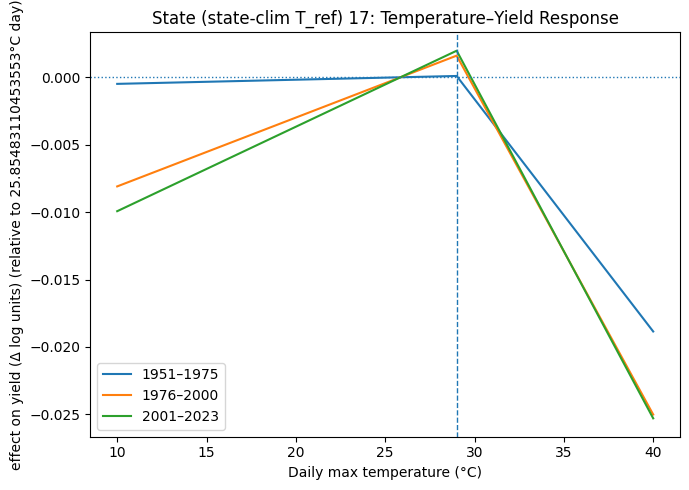

[PLOT-EPOCH-STATE] State 18: T_ref=25.33 °C


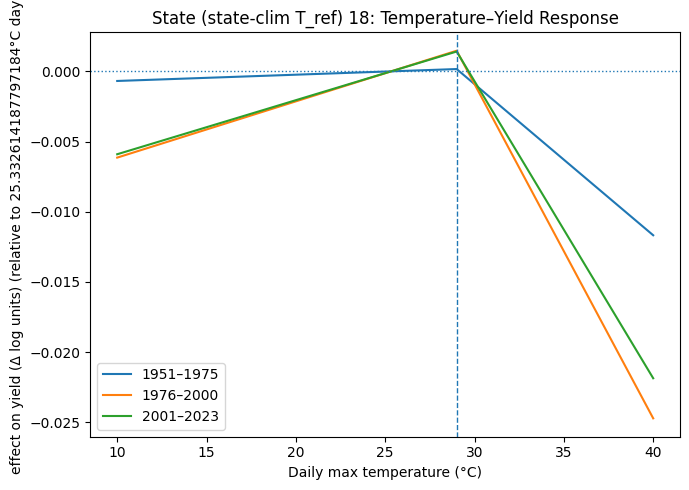

[PLOT-EPOCH-STATE] State 19: T_ref=24.35 °C


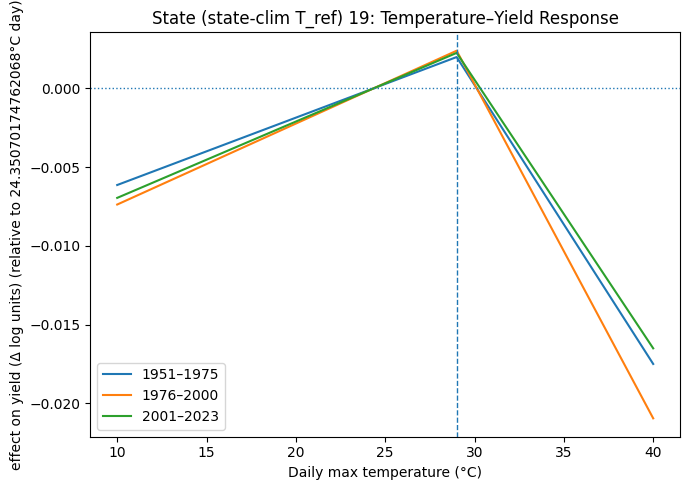

[PLOT-EPOCH-STATE] State 27: T_ref=22.11 °C


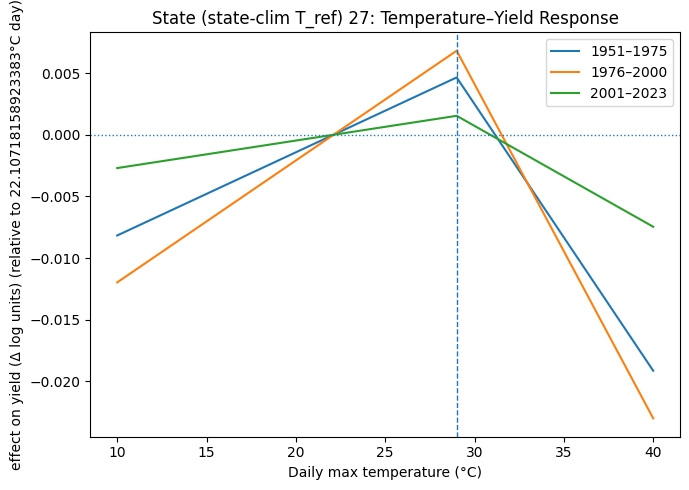

[PLOT-EPOCH-STATE] State 31: T_ref=25.48 °C


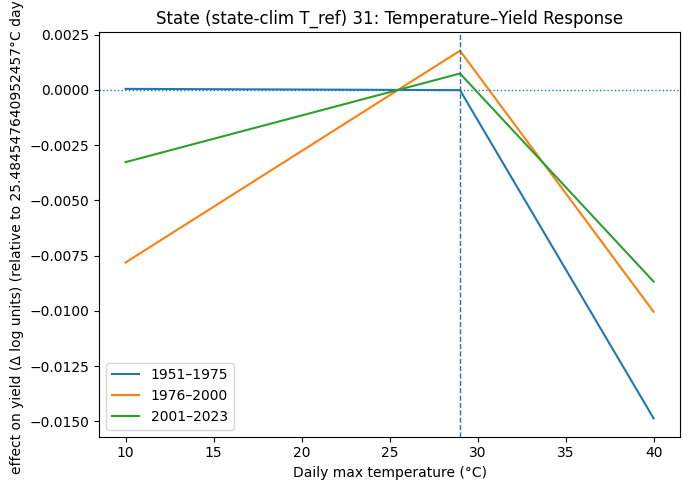

[PLOT-EPOCH-STATE] State 17_18_19_27: T_ref=24.63 °C


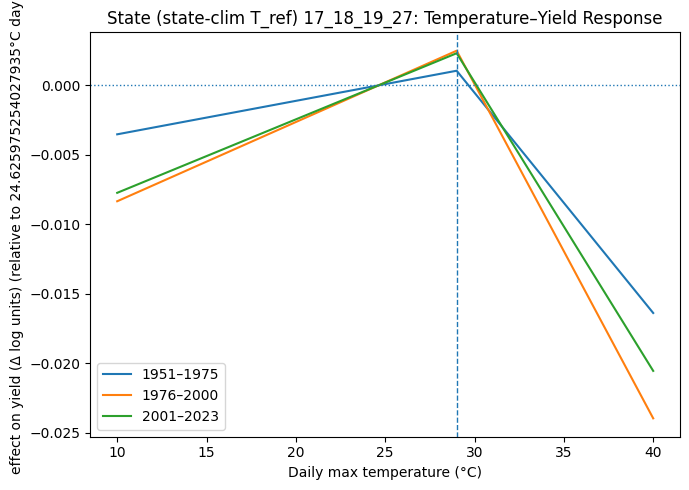

In [20]:
# ==============================
# CELL 6B — Epoch plots, state-specific climatological T_ref
# ==============================

# 3 epochs
EPOCHS_3 = (
    (1951, 1975),
    (1976, 2000),
    (2001, 2023),
)

ref_state = next(iter(proc_results.keys()))
years_ref = proc_results[ref_state]["years"]
epoch_windows = make_epoch_windows(years_ref, epochs=EPOCHS_3)
print(f"[WINDOWS-STATE] 3 epochs: {epoch_windows}")

# Climatology window (use same as before)
CLIM_YR_MIN, CLIM_YR_MAX = 1951, 2023
STATES_FOR_CLIM = ["17", "18", "19", "27", "31"]   # adjust if needed

tmax_col = find_tmax_column(df_master)
print(f"[TMAX] Using column: {tmax_col}")

# State-specific GS Tmax over climatology window
Tref_by_state_stateclim = compute_climatological_tref(
    df_master,
    tmax_col=tmax_col,
    mode="state",
    states=STATES_FOR_CLIM,
    clim_year_min=CLIM_YR_MIN,
    clim_year_max=CLIM_YR_MAX,
)

Tref_global_stateclim = float(np.mean(list(Tref_by_state_stateclim.values())))
print("[TREF-STATE] State-specific climatological T_ref (°C):")
for s, v in Tref_by_state_stateclim.items():
    print(f"   state {s}: {v:.2f}")
print(f"[TREF-STATE] Global fallback (mean across states): {Tref_global_stateclim:.2f} °C")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping epochs (state_clim).")
        continue

    # If this is a single state (e.g. "17", "18", ...), use its own T_ref.
    # For pooled code like "17_18_19_27", fall back to global mean.
    if st in Tref_by_state_stateclim:
        tref_use = Tref_by_state_stateclim[st]
    else:
        tref_use = Tref_global_stateclim

    print(f"[PLOT-EPOCH-STATE] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=epoch_windows,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State (state-clim T_ref)",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


### Epoch plots with county-climatology-aggregated Tref

[WINDOWS-COUNTY] 3 epochs: [(1951, 1975), (1976, 2000), (2001, 2023)]
[TMAX] Using column: TMAX_AVG_GS
[TREF-COUNTY] State-level T_ref from county climatology (°C):
   state 17: 25.85
   state 18: 25.33
   state 19: 24.35
   state 27: 22.11
   state 31: 25.48
[TREF-COUNTY] Global pooled T_ref (mean over all counties): 24.68 °C
[PLOT-EPOCH-COUNTY] State 17: T_ref=25.85 °C


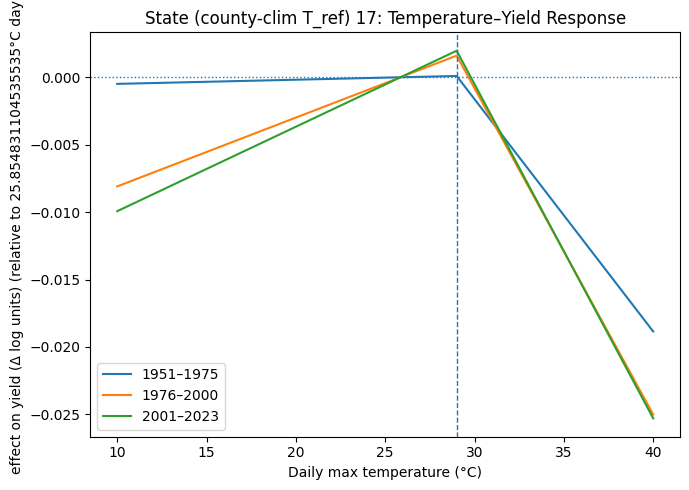

[PLOT-EPOCH-COUNTY] State 18: T_ref=25.33 °C


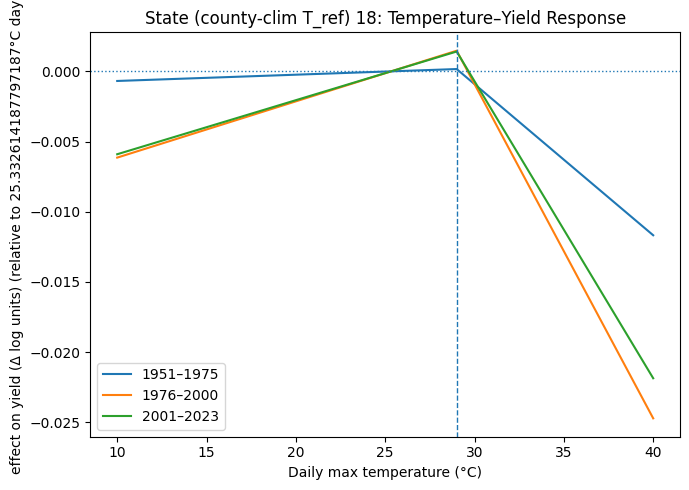

[PLOT-EPOCH-COUNTY] State 19: T_ref=24.35 °C


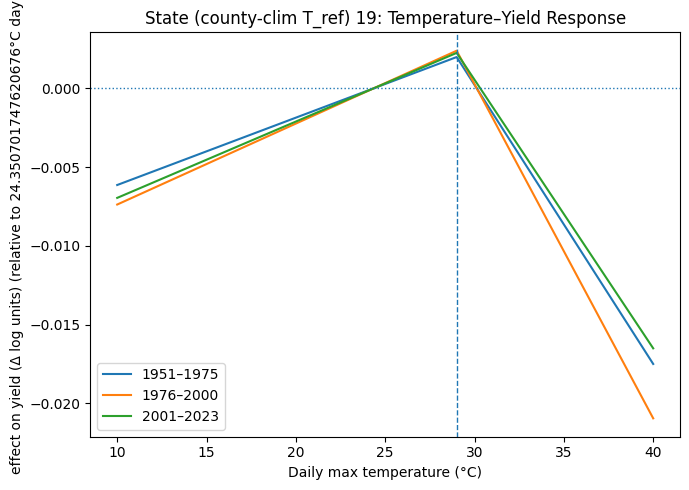

[PLOT-EPOCH-COUNTY] State 27: T_ref=22.11 °C


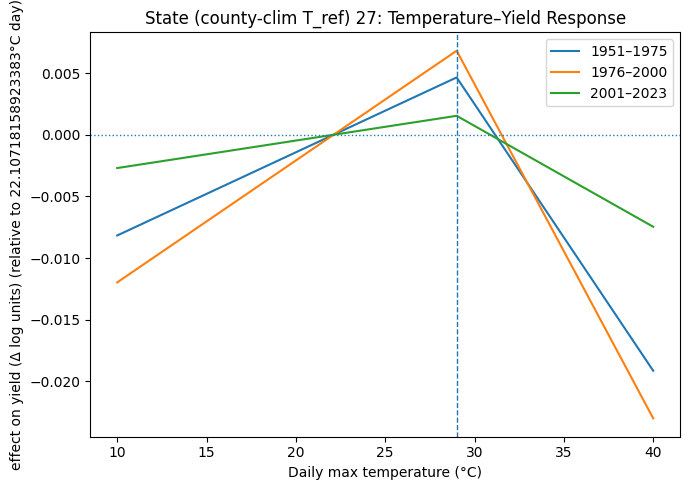

[PLOT-EPOCH-COUNTY] State 31: T_ref=25.48 °C


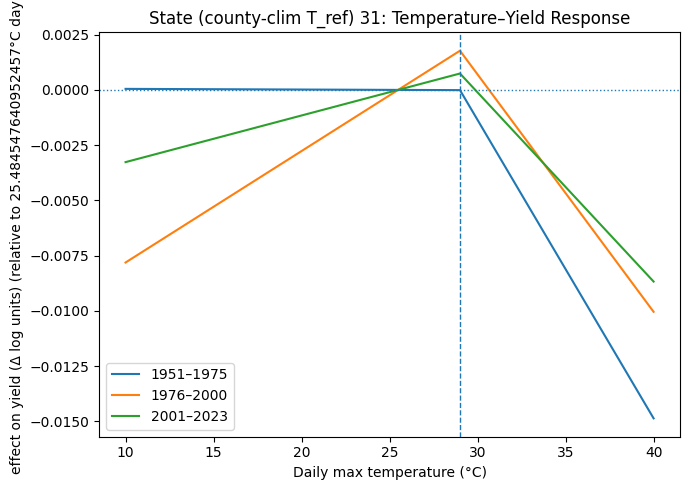

[PLOT-EPOCH-COUNTY] State 17_18_19_27: T_ref=24.68 °C


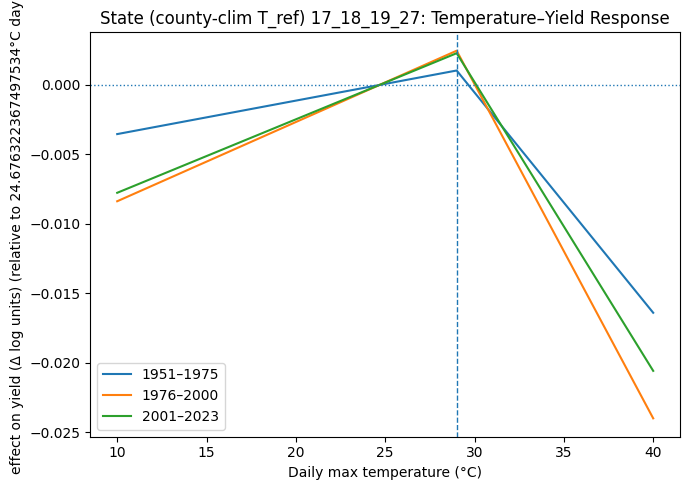

In [22]:
# ==============================
# CELL 6C — Epoch plots, county-climatology-based T_ref
# ==============================

# 3 epochs
EPOCHS_3 = (
    (1951, 1975),
    (1976, 2000),
    (2001, 2023),
)

ref_state = next(iter(proc_results.keys()))
years_ref = proc_results[ref_state]["years"]
epoch_windows = make_epoch_windows(years_ref, epochs=EPOCHS_3)
print(f"[WINDOWS-COUNTY] 3 epochs: {epoch_windows}")

CLIM_YR_MIN, CLIM_YR_MAX = 1951, 2023
STATES_FOR_CLIM = ["17", "18", "19", "27", "31"]

tmax_col = find_tmax_column(df_master)
print(f"[TMAX] Using column: {tmax_col}")

# Per-(state,county) climatological GS Tmax
county_clim_df = compute_climatological_tref(
    df_master,
    tmax_col=tmax_col,
    mode="county",
    states=STATES_FOR_CLIM,
    clim_year_min=CLIM_YR_MIN,
    clim_year_max=CLIM_YR_MAX,
)
# county_clim_df has columns: ['state','county','Tref_clim']

# State-level T_ref = mean across its counties
Tref_by_state_countyclim = (
    county_clim_df
    .groupby("state")["Tref_clim"]
    .mean()
    .to_dict()
)

# Pooled T_ref = mean across all counties
Tref_global_countyclim = float(county_clim_df["Tref_clim"].mean())

print("[TREF-COUNTY] State-level T_ref from county climatology (°C):")
for s, v in Tref_by_state_countyclim.items():
    print(f"   state {s}: {v:.2f}")
print(f"[TREF-COUNTY] Global pooled T_ref (mean over all counties): {Tref_global_countyclim:.2f} °C")

for st in STATES_TO_PLOT:
    if st not in proc_results:
        print(f"[WARN] No LLDVE results for {st}; skipping epochs (county_clim).")
        continue

    if st in Tref_by_state_countyclim:
        tref_use = Tref_by_state_countyclim[st]
    else:
        tref_use = Tref_global_countyclim

    print(f"[PLOT-EPOCH-COUNTY] State {st}: T_ref={tref_use:.2f} °C")

    plot_window_curves_for_state(
        state_code=st,
        state_block=proc_results[st],
        windows=epoch_windows,
        Tgrid=TGRID,
        Tref=tref_use,
        title_prefix="State (county-clim T_ref)",
        recenter=RECENTER,
        show_ci=SHOW_CI,
        scale=SCALE,
        show_actual_in_legend=True,
    )
    plt.show()


## Adaptation vs Maladaptation

### Step 1: σ-standardized GDD/KDD effects per epoch - functions

In [25]:
# ============================================================
# Step 1: σ-standardized GDD/KDD effects per epoch
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- (A) Helpers for reading anomaly SDs from master CSV ----------

def _find_anom_column(df, candidates, varname=""):
    """
    Small helper: find the first anomaly column that exists in df.
    """
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find a suitable column for {varname}. "
                   f"Tried: {candidates}")

def load_master_anomaly_sds(master_csv_path,
                            states_keep,
                            clim_start=1951,
                            clim_end=2023):
    """
    Load the master CSV and compute *unweighted* SDs of GDD and KDD anomalies
    over a climatological period (default 1951–2023) for a set of states.

    Returns:
      sigma_gdd, sigma_kdd   (floats, in same anomaly units as CSV)
    """
    df = pd.read_csv(master_csv_path)

    # standardize state codes to 2-digit strings
    if "state" not in df.columns:
        raise KeyError("Expected a 'state' column in master CSV.")
    df["state"] = df["state"].astype(str).str.zfill(2)
    df = df[df["state"].isin(states_keep)].copy()

    # make sure 'year' exists and is numeric
    if "year" not in df.columns:
        raise KeyError("Expected a 'year' column in master CSV.")
    df["year"] = df["year"].astype(int)

    # restrict to climatological window
    mask = (df["year"] >= clim_start) & (df["year"] <= clim_end)
    df_clim = df.loc[mask].copy()
    if df_clim.empty:
        raise ValueError(f"No data in climatological window {clim_start}–{clim_end}.")

    # find anomaly columns (robust to naming variants)
    col_gdd = _find_anom_column(
        df_clim,
        candidates=["GDD_GS_anom", "gdd_gs_anom", "GDD_anom_GS", "gdd_anom_gs"],
        varname="GDD anomalies"
    )
    col_kdd = _find_anom_column(
        df_clim,
        candidates=["KDD_GS_anom", "kdd_gs_anom", "KDD_anom_GS", "kdd_anom_gs"],
        varname="KDD anomalies"
    )

    # compute SD over all state×year observations
    sigma_gdd = df_clim[col_gdd].astype(float).std(ddof=1)
    sigma_kdd = df_clim[col_kdd].astype(float).std(ddof=1)

    print(f"[σ-anom] Using climatology {clim_start}–{clim_end}, "
          f"states {states_keep}")
    print(f"          SD(ΔGDD) = {sigma_gdd:.4f}, SD(ΔKDD) = {sigma_kdd:.4f}")

    return float(sigma_gdd), float(sigma_kdd)


# ---------- (B) Epoch-averaged betas from your LLDVE results ----------

def compute_epoch_avg_betas(proc_dict, pooled_state_code, epochs):
    """
    From your 'proc' dictionary (process_loaded_data output), extract pooled
    GDD/KDD betas and average them over the given epochs.

    Inputs:
      proc_dict          : dict from process_loaded_data(...)
      pooled_state_code  : e.g. "17_18_19_27"
      epochs             : list of (start_year, end_year) tuples

    Returns:
      DataFrame with columns:
        ['epoch_label','start_year','end_year','beta_GDD','beta_KDD']
    """
    if pooled_state_code not in proc_dict:
        raise KeyError(f"Pooled state code '{pooled_state_code}' not found in proc_dict.")

    block = proc_dict[pooled_state_code]
    years = np.asarray(block["years"], dtype=int)
    bG = np.asarray(block["gdd_coeffs"], dtype=float)
    bK = np.asarray(block["kdd_coeffs"], dtype=float)

    rows = []
    for (y0, y1) in epochs:
        y0, y1 = int(y0), int(y1)
        mask = (years >= y0) & (years <= y1)
        if not mask.any():
            print(f"[epoch-betas] Warning: no years in {y0}–{y1} for pooled {pooled_state_code}. Skipping.")
            continue

        beta_gdd_avg = bG[mask].mean()
        beta_kdd_avg = bK[mask].mean()
        label = f"{y0}–{y1}"
        rows.append({
            "epoch_label": label,
            "start_year": y0,
            "end_year": y1,
            "beta_GDD": beta_gdd_avg,
            "beta_KDD": beta_kdd_avg
        })

    df_epochs = pd.DataFrame(rows)
    return df_epochs


# ---------- (C) σ-standardized effects + heat-damage ratio ----------

def compute_sigma_standardized_epoch_effects(df_epoch_betas,
                                             sigma_gdd,
                                             sigma_kdd,
                                             eps=1e-8):
    """
    Given epoch-average betas and SDs of anomalies, compute:

      E_GDD = beta_GDD * σ_ΔGDD
      E_KDD = beta_KDD * σ_ΔKDD

    (Δ log yield per +1σ anomaly)

    And also:
      - percent versions: 100*(exp(E) - 1)
      - heat-damage ratio:
          R = |E_KDD| / (|E_GDD| + eps)

    Returns:
      DataFrame = original columns + added:
        ['E_GDD_log','E_KDD_log','E_GDD_pct','E_KDD_pct','heat_damage_ratio']
    """
    df = df_epoch_betas.copy()

    # log-units effects
    df["E_GDD_log"] = df["beta_GDD"] * sigma_gdd
    df["E_KDD_log"] = df["beta_KDD"] * sigma_kdd

    # convert to percent effects (approximate yield % change)
    df["E_GDD_pct"] = 100.0 * (np.exp(df["E_GDD_log"]) - 1.0)
    df["E_KDD_pct"] = 100.0 * (np.exp(df["E_KDD_log"]) - 1.0)

    # heat damage ratio: how large |KDD effect| is relative to |GDD effect|
    abs_g = np.abs(df["E_GDD_log"])
    abs_k = np.abs(df["E_KDD_log"])
    df["heat_damage_ratio"] = abs_k / (abs_g + eps)

    return df


# ---------- (D) Simple plot helper ----------

def plot_sigma_standardized_epoch_effects(df_sigma,
                                          title_suffix="(Pooled IL+IN+IA+MN)",
                                          show_ratio=True):
    """
    Simple bar plot:
      - Bars: E_GDD_pct (benefit) and E_KDD_pct (loss) per epoch
      - Optional: print heat_damage_ratio in text above the bars
    """
    epochs = df_sigma["epoch_label"].tolist()
    x = np.arange(len(epochs))

    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, df_sigma["E_GDD_pct"], width, label="GDD effect (+1σ)", alpha=0.8)
    ax.bar(x + width/2, df_sigma["E_KDD_pct"], width, label="KDD effect (+1σ)", alpha=0.8)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(epochs, rotation=0)
    ax.set_ylabel("Yield impact for +1σ anomaly (%)")
    ax.set_title(f"σ-standardized GDD/KDD effects by epoch {title_suffix}")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    if show_ratio and "heat_damage_ratio" in df_sigma.columns:
        for xi, r in zip(x, df_sigma["heat_damage_ratio"]):
            ax.text(xi, max(df_sigma["E_GDD_pct"].max(), df_sigma["E_KDD_pct"].max()) * 0.05,
                    f"R={r:.2f}",
                    ha="center", va="bottom", fontsize=9, rotation=0)

    plt.tight_layout()
    plt.show()


### Step 1: Run σ-standardized epoch effects for the pooled panel

[σ-anom] Using climatology 1951–2023, states ['17', '18', '19', '27']
          SD(ΔGDD) = 124.1007, SD(ΔKDD) = 63.5961
Epoch-average betas (log-yield units):


,epoch_label,start_year,end_year,beta_GDD,beta_KDD
0,1951–1975,1951,1975,0.000241,-0.001585
1,1976–2000,1976,2000,0.000570,-0.002405
2,2001–2023,2001,2023,0.000529,-0.002078


σ-standardized effects and heat-damage ratio:


,epoch_label,start_year,end_year,beta_GDD,beta_KDD,E_GDD_log,E_KDD_log,E_GDD_pct,E_KDD_pct,heat_damage_ratio
0,1951–1975,1951,1975,0.000241,-0.001585,0.029893,-0.100800,3.034436,-9.588616,3.372017
1,1976–2000,1976,2000,0.000570,-0.002405,0.070765,-0.152964,7.332923,-14.183967,2.161574
2,2001–2023,2001,2023,0.000529,-0.002078,0.065621,-0.132172,6.782169,-12.380987,2.014182


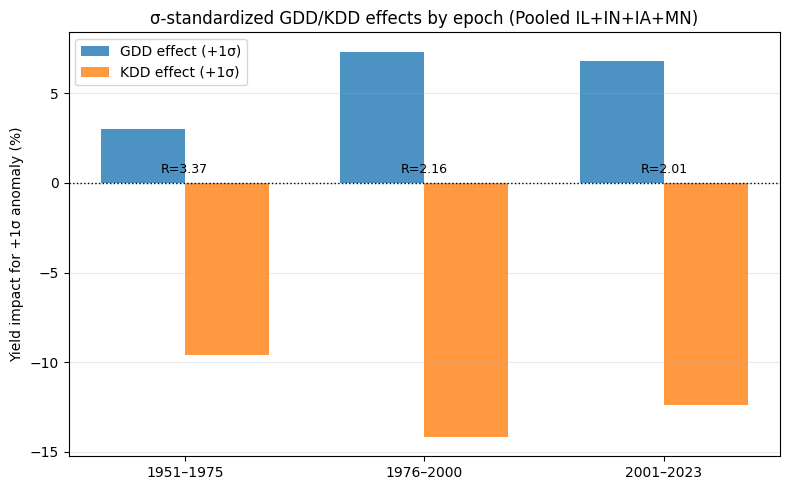

In [27]:
# ============================================================
# Step 1: Run σ-standardized epoch effects for the pooled panel
# ============================================================

# Make sure we have a variable name that matches what the helper expects
# (compute_epoch_avg_betas uses proc_dict=...)
proc_dict = proc_results   # <--- alias; proc_results came from process_loaded_data(raw_results)

# --- Config ---

MASTER_CSV_PATH = "master_panel_corn.csv"  # adjust if needed
STATES_FOR_REGION = ["17", "18", "19", "27"]     # IL, IN, IA, MN
POOLED_STATE_CODE = "17_18_19_27"                # pooled LLDVE run

# Our three epochs (you can tweak bounds if you like)
EPOCHS_3 = [
    (1951, 1975),
    (1976, 2000),
    (2001, 2023),
]

CLIM_START, CLIM_END = 1951, 2023   # climatological window for anomaly SDs

# --- 1. Compute SDs of GDD/KDD anomalies over climatology ---

sigma_gdd, sigma_kdd = load_master_anomaly_sds(
    master_csv_path=MASTER_CSV_PATH,
    states_keep=STATES_FOR_REGION,
    clim_start=CLIM_START,
    clim_end=CLIM_END
)

# --- 2. Compute epoch-averaged betas for the pooled state ---

df_epoch_betas = compute_epoch_avg_betas(
    proc_dict=proc_dict,
    pooled_state_code=POOLED_STATE_CODE,
    epochs=EPOCHS_3
)

print("Epoch-average betas (log-yield units):")
display(df_epoch_betas)

# --- 3. Combine betas + SDs into σ-standardized effects ---

df_sigma = compute_sigma_standardized_epoch_effects(
    df_epoch_betas=df_epoch_betas,
    sigma_gdd=sigma_gdd,
    sigma_kdd=sigma_kdd
)

print("σ-standardized effects and heat-damage ratio:")
display(df_sigma)

# --- 4. Quick visualization ---

plot_sigma_standardized_epoch_effects(df_sigma)



### Step 2: Yearly σ-standardized effects & heat-damage ratio - functions

In [29]:
# ============================================================
# Step 2: Yearly σ-standardized effects & heat-damage ratio
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_yearly_sigma_effects(proc_dict,
                                 pooled_state_code,
                                 sigma_gdd,
                                 sigma_kdd,
                                 eps=1e-8):
    """
    Build a yearly series of σ-standardized GDD/KDD effects for the pooled run.

    For each year t:
      E_GDD_log(t) = beta_GDD(t) * σ_ΔGDD
      E_KDD_log(t) = beta_KDD(t) * σ_ΔKDD
      E_*_pct(t)   = 100*(exp(E_*_log(t)) - 1)
      R(t)         = |E_KDD_log(t)| / (|E_GDD_log(t)| + eps)

    Inputs
    ------
    proc_dict        : your process_loaded_data(...) output (e.g. proc_results)
    pooled_state_code: e.g. "17_18_19_27"
    sigma_gdd        : SD of GDD anomalies (from Step 1)
    sigma_kdd        : SD of KDD anomalies (from Step 1)

    Returns
    -------
    df_year : DataFrame with columns
      ['year','beta_GDD','beta_KDD',
       'E_GDD_log','E_KDD_log','E_GDD_pct','E_KDD_pct',
       'heat_damage_ratio']
    """
    if pooled_state_code not in proc_dict:
        raise KeyError(f"Pooled state code '{pooled_state_code}' not found in proc_dict.")

    block = proc_dict[pooled_state_code]
    years = np.asarray(block["years"], dtype=int)
    bG    = np.asarray(block["gdd_coeffs"], dtype=float)
    bK    = np.asarray(block["kdd_coeffs"], dtype=float)

    # log-unit effects for +1σ anomaly
    E_GDD_log = bG * sigma_gdd
    E_KDD_log = bK * sigma_kdd

    # percent effects
    E_GDD_pct = 100.0 * (np.exp(E_GDD_log) - 1.0)
    E_KDD_pct = 100.0 * (np.exp(E_KDD_log) - 1.0)

    # heat-damage ratio
    abs_g = np.abs(E_GDD_log)
    abs_k = np.abs(E_KDD_log)
    R     = abs_k / (abs_g + eps)

    df = pd.DataFrame({
        "year": years,
        "beta_GDD": bG,
        "beta_KDD": bK,
        "E_GDD_log": E_GDD_log,
        "E_KDD_log": E_KDD_log,
        "E_GDD_pct": E_GDD_pct,
        "E_KDD_pct": E_KDD_pct,
        "heat_damage_ratio": R
    }).sort_values("year")

    return df.reset_index(drop=True)


def summarize_heat_damage_trend(df_year_sigma, epochs=None):
    """
    Summarize:
      - linear trend in R(t) over time
      - mean R per epoch (optional)

    Returns
    -------
    intercept, slope, df_epoch_means (or None)
    """
    years = df_year_sigma["year"].values.astype(float)
    R     = df_year_sigma["heat_damage_ratio"].values.astype(float)

    # fit R_t = a + b * year
    b, a = np.polyfit(years, R, 1)

    print(f"[trend] R_t ≈ {a:.2f} + {b:.4f} * year")
    print(f"        Slope b = {b:.4f} (change in ratio per calendar year)")

    epoch_means = None
    if epochs is not None:
        rows = []
        for (y0, y1) in epochs:
            mask = (df_year_sigma["year"] >= y0) & (df_year_sigma["year"] <= y1)
            if not mask.any():
                continue
            rows.append({
                "epoch_label": f"{y0}–{y1}",
                "start_year": y0,
                "end_year": y1,
                "mean_ratio": df_year_sigma.loc[mask, "heat_damage_ratio"].mean()
            })
        if rows:
            epoch_means = pd.DataFrame(rows)
            print("\nMean heat-damage ratio by epoch:")
            display(epoch_means)

    return a, b, epoch_means


def plot_yearly_sigma_effects(df_year_sigma,
                              title_suffix="(Pooled IL+IN+IA+MN)"):
    """
    Time series of +1σ GDD/KDD effects (in %) by year.
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(df_year_sigma["year"], df_year_sigma["E_GDD_pct"],
            label="GDD effect (+1σ)", linewidth=2)
    ax.plot(df_year_sigma["year"], df_year_sigma["E_KDD_pct"],
            label="KDD effect (+1σ)", linewidth=2)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield impact (%) for +1σ anomaly")
    ax.set_title(f"σ-standardized GDD/KDD effects over time {title_suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_heat_damage_ratio(df_year_sigma,
                           epochs=None,
                           title_suffix="(Pooled IL+IN+IA+MN)"):
    """
    Time series of R(t) = |KDD| / |GDD| with optional horizontal lines for
    epoch means.
    """
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(df_year_sigma["year"], df_year_sigma["heat_damage_ratio"],
            label="R(t) = |KDD| / |GDD|", linewidth=2)

    if epochs is not None:
        # add mean line for each epoch
        for (y0, y1) in epochs:
            mask = (df_year_sigma["year"] >= y0) & (df_year_sigma["year"] <= y1)
            if not mask.any():
                continue
            mean_r = df_year_sigma.loc[mask, "heat_damage_ratio"].mean()
            ax.hlines(mean_r, y0, y1,
                      colors="gray", linestyles="--", linewidth=1.5)
            ax.text((y0 + y1) / 2.0, mean_r,
                    f"{y0}–{y1}: {mean_r:.2f}",
                    ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Year")
    ax.set_ylabel("Heat-damage ratio R(t)")
    ax.set_title(f"Ratio of KDD to GDD damage over time {title_suffix}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Step 2: Run yearly σ-standardized series & heat-damage trend - functions

,year,beta_GDD,beta_KDD,E_GDD_log,E_KDD_log,E_GDD_pct,E_KDD_pct,heat_damage_ratio
0,1951,0.000484,-0.001413,0.060079,-0.089853,6.192029,-8.593456,1.495586
1,1952,0.000400,-0.001362,0.049591,-0.086621,5.084084,-8.297500,1.746711
2,1953,0.000342,-0.001336,0.042461,-0.084962,4.337581,-8.145260,2.000916
3,1954,0.000303,-0.001337,0.037638,-0.085022,3.835497,-8.150832,2.258969
4,1955,0.000272,-0.001349,0.033759,-0.085818,3.433567,-8.223894,2.542056


[trend] R_t ≈ 64.57 + -0.0312 * year
        Slope b = -0.0312 (change in ratio per calendar year)

Mean heat-damage ratio by epoch:


,epoch_label,start_year,end_year,mean_ratio
0,1951–1975,1951,1975,3.767176
1,1976–2000,1976,2000,2.193055
2,2001–2023,2001,2023,2.000333


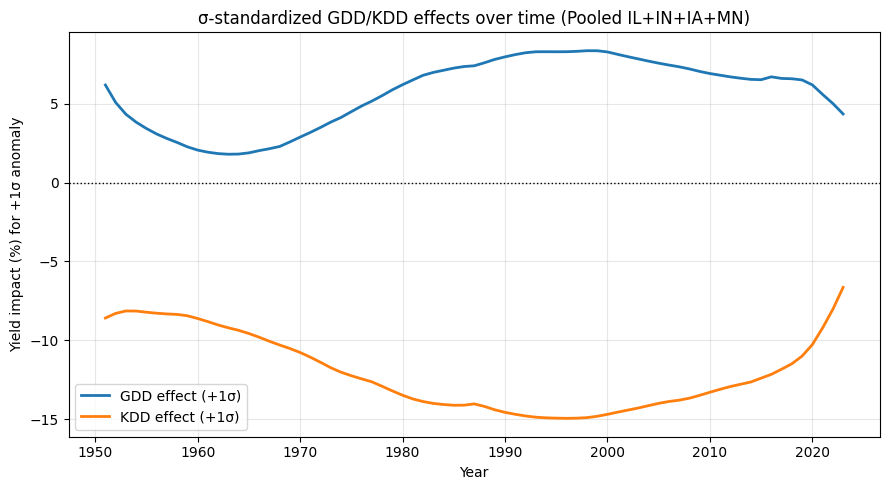

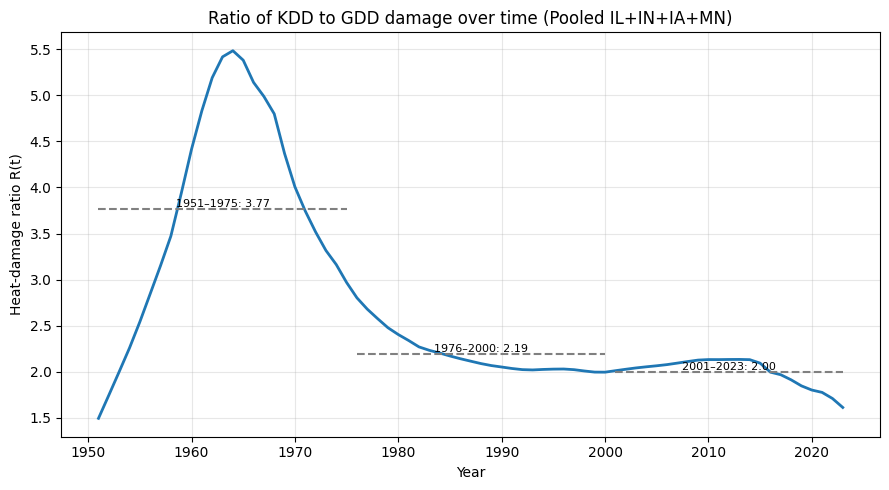

In [32]:
# ============================================================
# Step 2: Run yearly σ-standardized series & heat-damage trend
# ============================================================

# Re-use from earlier in the notebook:
# - proc_results       (from process_loaded_data(raw))
# - sigma_gdd, sigma_kdd (from your existing Step 1)
# - EPOCHS_3           (1951–75, 76–00, 01–23)

proc_dict         = proc_results
POOLED_STATE_CODE = "17_18_19_27"

# 1. Build yearly σ-standardized effects
df_year_sigma = compute_yearly_sigma_effects(
    proc_dict=proc_dict,
    pooled_state_code=POOLED_STATE_CODE,
    sigma_gdd=sigma_gdd,
    sigma_kdd=sigma_kdd
)
display(df_year_sigma.head())

# 2. Summarise trend + epoch means for the ratio
trend_intercept, trend_slope, epoch_mean_R = summarize_heat_damage_trend(
    df_year_sigma,
    epochs=EPOCHS_3
)

# 3. Plots
plot_yearly_sigma_effects(df_year_sigma)
plot_heat_damage_ratio(df_year_sigma, epochs=EPOCHS_3)


### Step 3 – Functions for fixed-anomaly adaptation trajectory

In [36]:
# ============================================================
# Step 3 – Fixed-anomaly adaptation trajectory (functions)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NOTE: we assume _find_anom_column(...) from Step 1 is already defined.
# If not, run the Step 1 cell first.


# ---------- (A) Load region-aggregated anomalies for fixed-vector selection ----------

def load_region_anomalies_for_fixed_vector(master_csv_path,
                                           states_keep,
                                           clim_start=1951,
                                           clim_end=2023,
                                           weight_col=None):
    """
    Load GDD/KDD GS anomalies for the selected states and aggregate them
    to a single 'region-year' series.

    Returns
    -------
    region_year : DataFrame indexed by year with columns ['GDD_anom','KDD_anom']
    """
    df = pd.read_csv(master_csv_path)

    # standardize state codes
    if "state" not in df.columns:
        raise KeyError("Expected a 'state' column in master CSV.")
    df["state"] = df["state"].astype(str).str.zfill(2)
    df = df[df["state"].isin(states_keep)].copy()

    if "year" not in df.columns:
        raise KeyError("Expected a 'year' column in master CSV.")
    df["year"] = df["year"].astype(int)

    # restrict to climatological window (or full sample)
    mask = (df["year"] >= clim_start) & (df["year"] <= clim_end)
    df = df.loc[mask].copy()
    if df.empty:
        raise ValueError(f"No data in {clim_start}–{clim_end} for states {states_keep}.")

    # anomaly columns (re-use robust helper from Step 1)
    col_gdd = _find_anom_column(
        df,
        candidates=["GDD_GS_anom", "gdd_gs_anom", "GDD_anom_GS", "gdd_anom_gs"],
        varname="GDD anomalies"
    )
    col_kdd = _find_anom_column(
        df,
        candidates=["KDD_GS_anom", "kdd_gs_anom", "KDD_anom_GS", "kdd_anom_gs"],
        varname="KDD anomalies"
    )

    # optional weights (e.g. production); default = equal weights
    if (weight_col is not None) and (weight_col in df.columns):
        w_df = (df.groupby(["state", "year"])[weight_col]
                  .sum()
                  .reset_index()
                  .rename(columns={weight_col: "_w"}))
    else:
        # each county/year gets weight 1
        w_df = (df.assign(_w=1.0)
                  .groupby(["state", "year"])["_w"]
                  .sum()
                  .reset_index())

    # mean anomalies per state/year
    anom_state_year = (df.groupby(["state", "year"])[[col_gdd, col_kdd]]
                         .mean()
                         .reset_index())

    # merge weights
    anom_state_year = anom_state_year.merge(w_df, on=["state", "year"], how="left")

    # aggregate to region-year using weights
    def _weighted_pool(g):
        w = g["_w"].to_numpy()
        w = np.where(np.isfinite(w) & (w > 0), w, 1.0)
        gdd = np.average(g[col_gdd].to_numpy(), weights=w)
        kdd = np.average(g[col_kdd].to_numpy(), weights=w)
        return pd.Series({"GDD_anom": gdd, "KDD_anom": kdd})

    region_year = (anom_state_year
                   .groupby("year")
                   .apply(_weighted_pool)
                   .sort_index())

    print(f"[fixed-anom] Region anomalies loaded: years {region_year.index.min()}–{region_year.index.max()}, "
          f"n_years={len(region_year)}")
    return region_year


# ---------- (B) Choose a fixed anomaly vector Δ* ----------

def choose_fixed_anomaly_vector(region_year_anoms,
                                sigma_gdd=None,
                                sigma_kdd=None,
                                mode="sigma",
                                tail_q=0.8):
    """
    Construct a non-zero fixed anomaly vector (ΔGDD*, ΔKDD*).

    Modes
    -----
    mode = "sigma":
        ΔGDD* = +σ_ΔGDD
        ΔKDD* = +σ_ΔKDD
        (uses sigma_gdd, sigma_kdd from Step 1)

    mode = "hot_tail":
        use the mean anomalies of the hottest 'tail_q' fraction of years,
        where 'hot' is defined by KDD_anom (e.g. top 20% if tail_q=0.8).

    Returns
    -------
    dG_fix, dK_fix, description_str
    """
    if mode == "sigma":
        if sigma_gdd is None or sigma_kdd is None:
            raise ValueError("sigma_gdd and sigma_kdd must be provided for mode='sigma'.")
        dG_fix = float(sigma_gdd)
        dK_fix = float(sigma_kdd)
        desc = f"+1σ anomalies: ΔGDD*={dG_fix:.3f}, ΔKDD*={dK_fix:.3f}"

    elif mode == "hot_tail":
        # select 'hot' years by KDD_anom
        k = region_year_anoms["KDD_anom"].to_numpy()
        thr = np.quantile(k, tail_q)
        hot = region_year_anoms[k >= thr]
        if hot.empty:
            raise ValueError(f"No hot years found for tail_q={tail_q}.")
        dG_fix = float(hot["GDD_anom"].mean())
        dK_fix = float(hot["KDD_anom"].mean())
        desc = (f"hot-tail (KDD >= {tail_q:.2f} quantile): "
                f"ΔGDD*={dG_fix:.3f}, ΔKDD*={dK_fix:.3f}, n_hot={len(hot)}")

    else:
        raise ValueError("mode must be 'sigma' or 'hot_tail'.")

    print(f"[fixed-anom] Using fixed vector: {desc}")
    return dG_fix, dK_fix, desc


# ---------- (C) Compute fixed-anomaly trajectory from LLDVE betas ----------

def compute_fixed_anomaly_trajectory(proc_dict,
                                     pooled_state_code,
                                     dG_fix,
                                     dK_fix,
                                     ci=True,
                                     ci_low=2.5,
                                     ci_high=97.5):
    """
    For each year t, compute:

      G_part_fix(t) = β_GDD(t) * ΔGDD*
      K_part_fix(t) = β_KDD(t) * ΔKDD*
      NetImpact_fix(t) = G_part_fix(t) + K_part_fix(t)

    Optionally, use bootstrap draws (gdd_draws, kdd_draws) from proc_dict
    to construct CI bands for NetImpact_fix(t).

    Returns
    -------
    df_fix : DataFrame with columns
      ['year','GDD_part_fix','KDD_part_fix','NetImpact_fix','lo','hi']
      (if ci=False, 'lo'/'hi' will be NaN)
    """
    if pooled_state_code not in proc_dict:
        raise KeyError(f"Pooled state '{pooled_state_code}' not found in proc_dict.")

    block = proc_dict[pooled_state_code]
    years = np.asarray(block["years"], dtype=int)
    bG    = np.asarray(block["gdd_coeffs"], dtype=float)
    bK    = np.asarray(block["kdd_coeffs"], dtype=float)

    # deterministic parts
    G_part = bG * dG_fix
    K_part = bK * dK_fix
    net    = G_part + K_part

    # bootstrap band (if draws present and ci=True)
    lo = np.full_like(net, np.nan, dtype=float)
    hi = np.full_like(net, np.nan, dtype=float)

    if ci and ("gdd_draws" in block) and ("kdd_draws" in block):
        BG = np.asarray(block["gdd_draws"], dtype=float)  # (B,T)
        BK = np.asarray(block["kdd_draws"], dtype=float)  # (B,T)
        if BG.shape == BK.shape and BG.shape[1] == len(years):
            net_boot = BG * dG_fix + BK * dK_fix           # (B,T)
            lo = np.percentile(net_boot, ci_low, axis=0)
            hi = np.percentile(net_boot, ci_high, axis=0)
        else:
            print("[fixed-anom] Warning: bootstrap shapes do not match T; CI omitted.")

    df_fix = pd.DataFrame({
        "year": years,
        "GDD_part_fix": G_part,
        "KDD_part_fix": K_part,
        "NetImpact_fix": net,
        "lo": lo,
        "hi": hi
    }).sort_values("year").reset_index(drop=True)

    return df_fix


# ---------- (D) Plot helpers ----------

def _to_percent(delta_log):
    x = np.asarray(delta_log, dtype=float)
    return 100.0 * (np.exp(x) - 1.0)

def plot_fixed_anomaly_net(df_fix,
                           percent=True,
                           label="Fixed anomaly net impact",
                           title_suffix="(Pooled IL+IN+IA+MN)"):
    """
    Plot NetImpact_fix(t) over time with optional CI band.
    """
    years = df_fix["year"].values
    net   = df_fix["NetImpact_fix"].values
    lo    = df_fix["lo"].values
    hi    = df_fix["hi"].values

    if percent:
        y  = _to_percent(net)
        ylo = _to_percent(lo)
        yhi = _to_percent(hi)
        ylabel = "Yield impact (%)"
    else:
        y  = net
        ylo = lo
        yhi = hi
        ylabel = "Δ log yield"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(years, y, label=label, linewidth=2)
    # Only fill CI if we have finite bounds
    if np.isfinite(ylo).any() and np.isfinite(yhi).any():
        ax.fill_between(years, ylo, yhi, alpha=0.2, label="95% CI")

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Fixed-anomaly adaptation trajectory {title_suffix}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_fixed_anomaly_decomposition(df_fix,
                                     percent=True,
                                     title_suffix="(Pooled IL+IN+IA+MN)"):
    """
    Decomposition plot: GDD_part_fix, KDD_part_fix, NetImpact_fix.
    """
    years = df_fix["year"].values
    G = df_fix["GDD_part_fix"].values
    K = df_fix["KDD_part_fix"].values
    net = df_fix["NetImpact_fix"].values

    if percent:
        Gp = _to_percent(G)
        Kp = _to_percent(K)
        Np = _to_percent(net)
        ylabel = "Yield impact (%)"
    else:
        Gp, Kp, Np = G, K, net
        ylabel = "Δ log yield"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(years, Np, label="Net impact (fixed anomalies)", linewidth=2)
    ax.plot(years, Gp, label="GDD contribution", linestyle="--")
    ax.plot(years, Kp, label="KDD contribution", linestyle="-.")

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Decomposition under fixed anomalies {title_suffix}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### Step 3 – Calling the fixed-anomaly functions

[fixed-anom] Region anomalies loaded: years 1951–2023, n_years=73
[fixed-anom] Using fixed vector: +1σ anomalies: ΔGDD*=124.101, ΔKDD*=63.596
[fixed-anom] Using fixed vector: hot-tail (KDD >= 0.80 quantile): ΔGDD*=121.129, ΔKDD*=86.205, n_hot=15


C:\Users\rickg\AppData\Local\Temp\ipykernel_10752\1111570996.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_weighted_pool)


,year,GDD_part_fix,KDD_part_fix,NetImpact_fix,lo,hi
0,1951,0.060079,-0.089853,-0.029774,-0.228858,0.107895
1,1952,0.049591,-0.086621,-0.037030,-0.212987,0.092283
2,1953,0.042461,-0.084962,-0.042500,-0.195092,0.075050
3,1954,0.037638,-0.085022,-0.047385,-0.179775,0.059821
4,1955,0.033759,-0.085818,-0.052059,-0.167553,0.046814


,year,GDD_part_fix,KDD_part_fix,NetImpact_fix,lo,hi
0,1951,0.058640,-0.121796,-0.063156,-0.282960,0.075275
1,1952,0.048403,-0.117414,-0.069011,-0.263524,0.057981
2,1953,0.041445,-0.115166,-0.073721,-0.249064,0.042026
3,1954,0.036736,-0.115248,-0.078512,-0.234189,0.028226
4,1955,0.032951,-0.116327,-0.083376,-0.221100,0.014668


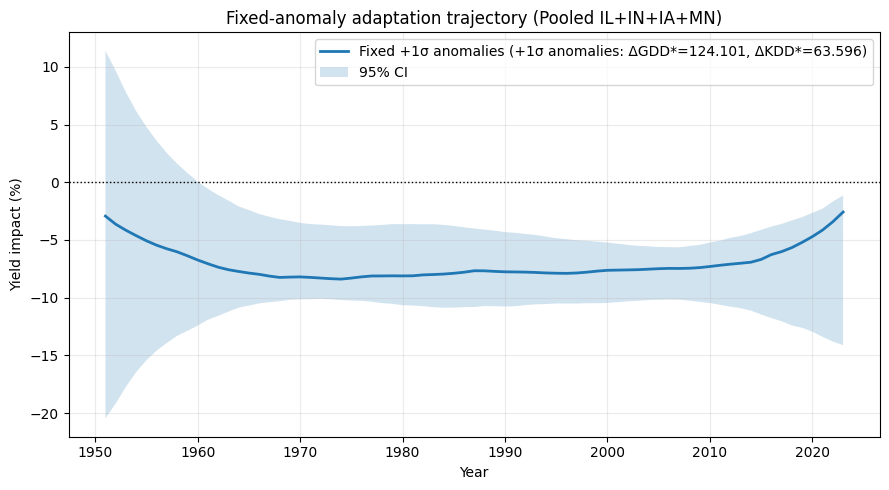

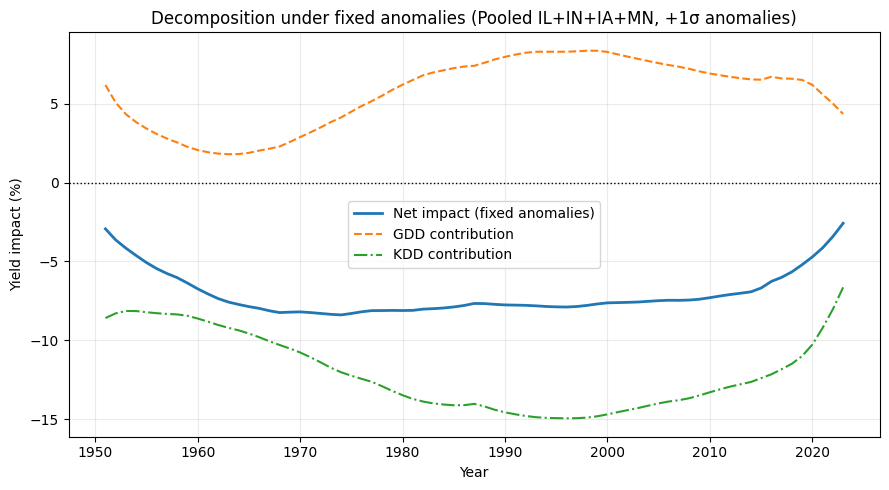

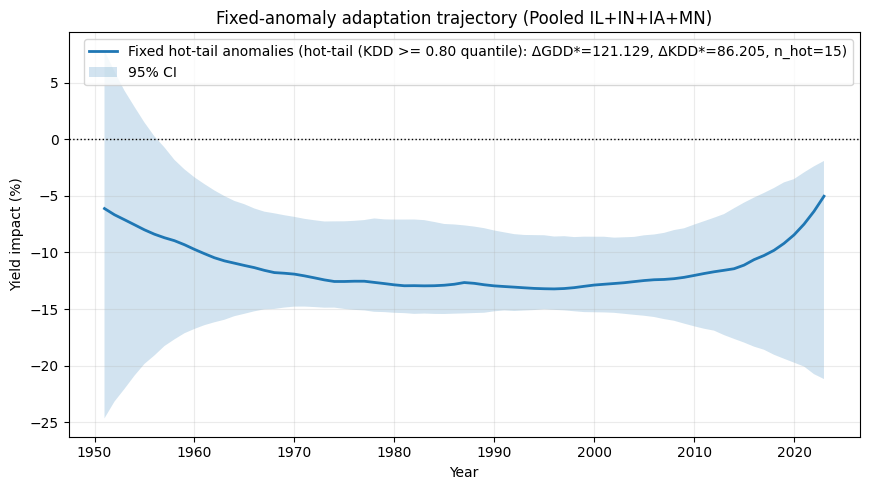

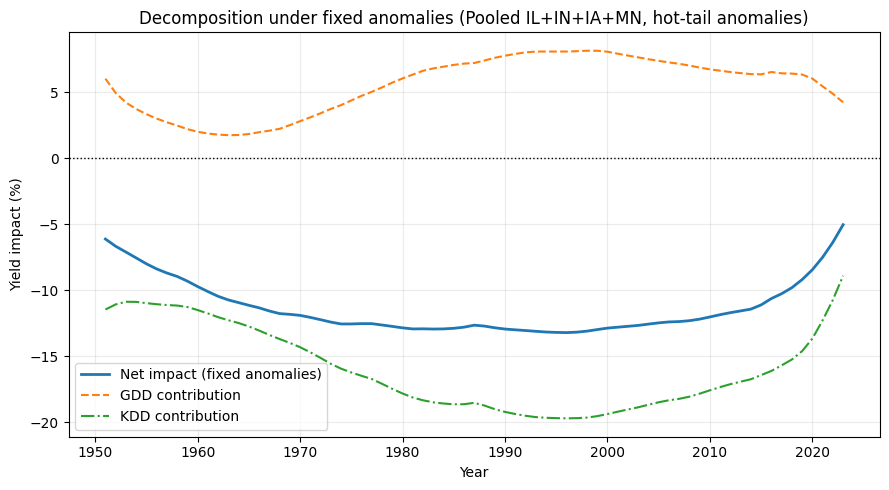

In [81]:
# ============================================================
# Step 3: Run fixed-anomaly adaptation trajectories
# ============================================================

# 1. Load region-level anomalies for the pooled Corn Belt states
region_year_anoms = load_region_anomalies_for_fixed_vector(
    master_csv_path=MASTER_CSV_PATH,
    states_keep=STATES_FOR_REGION,
    clim_start=CLIM_START,   # usually 1951
    clim_end=CLIM_END,       # usually 2023
    weight_col=None          # or e.g. "corn_production_tons" if you have it
)

# 2. Choose one or two fixed anomaly vectors

# (a) Balanced +1σ anomalies year
dG_sigma, dK_sigma, desc_sigma = choose_fixed_anomaly_vector(
    region_year_anoms=region_year_anoms,
    sigma_gdd=sigma_gdd,
    sigma_kdd=sigma_kdd,
    mode="sigma"
)

# (b) "Hot-tail" composite: typical hottest years (top 20% KDD)
dG_hot, dK_hot, desc_hot = choose_fixed_anomaly_vector(
    region_year_anoms=region_year_anoms,
    sigma_gdd=sigma_gdd,
    sigma_kdd=sigma_kdd,
    mode="hot_tail",
    tail_q=0.8   # top 20% KDD years
)

POOLED_STATE_CODE = "17_18_19_27"
proc_dict = proc_results   # alias for clarity

# 3. Compute trajectories for each fixed vector

df_fix_sigma = compute_fixed_anomaly_trajectory(
    proc_dict=proc_dict,
    pooled_state_code=POOLED_STATE_CODE,
    dG_fix=dG_sigma,
    dK_fix=dK_sigma,
    ci=True
)

df_fix_hot = compute_fixed_anomaly_trajectory(
    proc_dict=proc_dict,
    pooled_state_code=POOLED_STATE_CODE,
    dG_fix=dG_hot,
    dK_fix=dK_hot,
    ci=True
)

display(df_fix_sigma.head())
display(df_fix_hot.head())

# 4. Plots: net impact + decomposition, in percent units (easiest to interpret)

# (a) +1σ anomalies
plot_fixed_anomaly_net(
    df_fix_sigma,
    percent=True,
    label=f"Fixed +1σ anomalies ({desc_sigma})",
    title_suffix="(Pooled IL+IN+IA+MN)"
)
plot_fixed_anomaly_decomposition(
    df_fix_sigma,
    percent=True,
    title_suffix="(Pooled IL+IN+IA+MN, +1σ anomalies)"
)

# (b) Hot-tail anomalies (very warm years)
plot_fixed_anomaly_net(
    df_fix_hot,
    percent=True,
    label=f"Fixed hot-tail anomalies ({desc_hot})",
    title_suffix="(Pooled IL+IN+IA+MN)"
)
plot_fixed_anomaly_decomposition(
    df_fix_hot,
    percent=True,
    title_suffix="(Pooled IL+IN+IA+MN, hot-tail anomalies)"
)


### Step 4 – Functions: NetImpact under actual climate + epoch decomposition

In [40]:
# ============================================================
# Step 4 – NetImpact under actual climate (Idea 3)
#   Uses:
#   - pooled time-varying betas from LLDVE (proc_results)
#   - pooled regional anomalies from master CSV
#   to compute:
#      NetImpact_t = β_GDD(t) * ΔGDD_t + β_KDD(t) * ΔKDD_t
#   and decompose this by epoch.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- (A) Load state- and region-level anomalies ----------

def load_region_anomalies_from_master(master_csv_path,
                                      states_keep,
                                      agg="mean",
                                      weight_col=None):
    """
    Load GDD/KDD GS anomalies for a set of states from the master CSV and build:
      - state_year_anoms:  index [state, year] with columns ['GDD_anom','KDD_anom']
      - region_year_anoms: index [year]       with columns ['GDD_anom','KDD_anom']
    
    agg       : 'mean' or 'median' at the state-year level
    weight_col: optional column in master CSV to use as weights when pooling
                across states into a single regional series.
    """
    df = pd.read_csv(master_csv_path)

    # Standardise state + year
    if "state" not in df.columns:
        raise KeyError("Expected a 'state' column in master CSV.")
    if "year" not in df.columns:
        raise KeyError("Expected a 'year' column in master CSV.")

    df["state"] = df["state"].astype(str).str.zfill(2)
    df["year"]  = df["year"].astype(int)

    df = df[df["state"].isin(states_keep)].copy()
    if df.empty:
        raise ValueError(f"No rows for states {states_keep} in {master_csv_path}")

    # Find anomaly columns (reuse helper from Step 1)
    col_gdd = _find_anom_column(
        df,
        candidates=["GDD_GS_anom", "gdd_gs_anom", "GDD_anom_GS", "gdd_anom_gs"],
        varname="GDD anomalies"
    )
    col_kdd = _find_anom_column(
        df,
        candidates=["KDD_GS_anom", "kdd_gs_anom", "KDD_anom_GS", "kdd_anom_gs"],
        varname="KDD anomalies"
    )

    # 1) State-year aggregation
    group_keys = ["state", "year"]
    if agg.lower() == "median":
        state_year = (
            df.groupby(group_keys)[[col_gdd, col_kdd]]
              .median()
              .rename(columns={col_gdd: "GDD_anom", col_kdd: "KDD_anom"})
        )
    else:
        state_year = (
            df.groupby(group_keys)[[col_gdd, col_kdd]]
              .mean()
              .rename(columns={col_gdd: "GDD_anom", col_kdd: "KDD_anom"})
        )

    state_year = state_year.reset_index()

    # 2) Optional weights for pooling across states
    if (weight_col is not None) and (weight_col in df.columns):
        w = (
            df.groupby(group_keys)[weight_col]
              .sum()
              .reset_index()
              .rename(columns={weight_col: "_w"})
        )
        state_year = state_year.merge(w, on=group_keys, how="left")
    else:
        state_year["_w"] = 1.0

    # 3) Pool to a single regional anomaly series by year
    def _pool_row(g):
        w = g["_w"].to_numpy()
        w = np.where(np.isfinite(w) & (w > 0), w, 1.0)
        gdd = np.average(g["GDD_anom"].to_numpy(), weights=w)
        kdd = np.average(g["KDD_anom"].to_numpy(), weights=w)
        return pd.Series({"GDD_anom": gdd, "KDD_anom": kdd})

    region_year = (
        state_year.groupby("year")
                  .apply(_pool_row)
                  .sort_index()
    )

    # Tidy indices
    state_year = state_year.set_index(["state", "year"]).sort_index()
    region_year.index.name = "year"

    print(f"[anoms] Region anomalies years {region_year.index.min()}–{region_year.index.max()} "
          f"(n={len(region_year)})")

    return state_year, region_year


# ---------- (B) Yearly NetImpact under actual climate ----------

def compute_actual_climate_netimpact(proc_dict,
                                     pooled_state_code,
                                     region_year_anoms,
                                     ci_low=2.5,
                                     ci_high=97.5):
    """
    Combine time-varying pooled betas with regional anomalies to get a yearly
    series of:
        G_part_t = β_GDD(t) * ΔGDD_t
        K_part_t = β_KDD(t) * ΔKDD_t
        Net_t    = G_part_t + K_part_t
    
    Also uses bootstrap draws of β's to build a CI band for Net_t.

    Inputs
    ------
    proc_dict         : dict from process_loaded_data(...)
    pooled_state_code : e.g. "17_18_19_27"
    region_year_anoms : DataFrame indexed by year with ['GDD_anom','KDD_anom']
                        (the regional mean anomalies)

    Returns
    -------
    df_year : DataFrame with columns
      ['year','GDD_anom','KDD_anom',
       'GDD_part_log','KDD_part_log','NetImpact_log',
       'Net_lo_log','Net_hi_log']
    """
    if pooled_state_code not in proc_dict:
        raise KeyError(f"Pooled state code '{pooled_state_code}' not found in proc_dict.")

    block = proc_dict[pooled_state_code]
    years_beta = np.asarray(block["years"], dtype=int)
    bG         = np.asarray(block["gdd_coeffs"], dtype=float)
    bK         = np.asarray(block["kdd_coeffs"], dtype=float)
    BG         = np.asarray(block["gdd_draws"], dtype=float)  # (B,T)
    BK         = np.asarray(block["kdd_draws"], dtype=float)  # (B,T)

    # Ensure anomalies indexed by year
    reg = region_year_anoms.copy()
    if "year" in reg.columns or reg.index.name != "year":
        reg = reg.reset_index().set_index("year")
    reg = reg.sort_index()

    # Overlapping years
    common_years = np.intersect1d(years_beta, reg.index.values.astype(int))
    if common_years.size == 0:
        raise ValueError("No overlapping years between betas and region anomalies.")

    # Align everything to the same order
    common_years = np.sort(common_years)

    # positions of these years in beta arrays
    pos = pd.Series(np.arange(len(years_beta)), index=years_beta)
    idx_beta = pos.loc[common_years].to_numpy()

    bG_sel = bG[idx_beta]
    bK_sel = bK[idx_beta]
    BG_sel = BG[:, idx_beta]
    BK_sel = BK[:, idx_beta]

    dG = reg.loc[common_years, "GDD_anom"].to_numpy(dtype=float)
    dK = reg.loc[common_years, "KDD_anom"].to_numpy(dtype=float)

    # Deterministic log-unit contributions
    G_part = bG_sel * dG
    K_part = bK_sel * dK
    Net    = G_part + K_part

    # Bootstrap NetImpact CI
    net_boot = BG_sel * dG[None, :] + BK_sel * dK[None, :]
    lo = np.percentile(net_boot, ci_low, axis=0)
    hi = np.percentile(net_boot, ci_high, axis=0)

    df_year = pd.DataFrame({
        "year": common_years.astype(int),
        "GDD_anom": dG,
        "KDD_anom": dK,
        "GDD_part_log": G_part,
        "KDD_part_log": K_part,
        "NetImpact_log": Net,
        "Net_lo_log": lo,
        "Net_hi_log": hi
    }).sort_values("year").reset_index(drop=True)

    return df_year


# ---------- (C) Epoch-level decomposition summariser ----------

def summarise_netimpact_by_epoch(df_year_impact, epochs):
    """
    Aggregate yearly NetImpact decomposition by epoch.

    For each epoch [y0,y1], compute:
      - mean GDD_part_log
      - mean KDD_part_log
      - mean NetImpact_log
      - number of years used

    Returns a DataFrame with one row per epoch.
    """
    rows = []
    for (y0, y1) in epochs:
        y0, y1 = int(y0), int(y1)
        mask = (df_year_impact["year"] >= y0) & (df_year_impact["year"] <= y1)
        if not mask.any():
            print(f"[epoch-net] No overlapping years for {y0}–{y1}; skipping.")
            continue
        sub = df_year_impact.loc[mask]

        rows.append({
            "epoch_label": f"{y0}–{y1}",
            "start_year": y0,
            "end_year": y1,
            "mean_GDD_log": sub["GDD_part_log"].mean(),
            "mean_KDD_log": sub["KDD_part_log"].mean(),
            "mean_Net_log": sub["NetImpact_log"].mean(),
            "n_years": int(mask.sum())
        })

    return pd.DataFrame(rows)


# ---------- (D) Simple plotting helpers ----------

def _log_to_pct(x):
    x = np.asarray(x, dtype=float)
    return 100.0 * (np.exp(x) - 1.0)

def plot_epoch_netimpact_decomposition(df_epoch,
                                       title_suffix="(Pooled IL+IN+IA+MN)",
                                       percent=True):
    """
    Bar plot by epoch, showing mean GDD and KDD contributions, plus Net impact.

    If percent=True, convert log-units to approximate % effects.
    """
    epochs = df_epoch["epoch_label"].tolist()
    x = np.arange(len(epochs))

    if percent:
        g = _log_to_pct(df_epoch["mean_GDD_log"].values)
        k = _log_to_pct(df_epoch["mean_KDD_log"].values)
        net = _log_to_pct(df_epoch["mean_Net_log"].values)
        ylabel = "Yield impact under actual climate (mean per epoch, %)"
    else:
        g = df_epoch["mean_GDD_log"].values
        k = df_epoch["mean_KDD_log"].values
        net = df_epoch["mean_Net_log"].values
        ylabel = "Mean Δ log yield under actual climate"

    width = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width, g, width, label="GDD contribution", alpha=0.8)
    ax.bar(x,         k, width, label="KDD contribution", alpha=0.8)
    ax.bar(x + width, net, width, label="Net impact", alpha=0.8)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(epochs)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Actual-climate GDD/KDD decomposition by epoch {title_suffix}")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_actual_netimpact_time_series(df_year_impact,
                                      title_suffix="(Pooled IL+IN+IA+MN)",
                                      percent=True):
    """
    Time series of yearly NetImpact and its GDD/KDD components under actual climate.
    """
    years = df_year_impact["year"].values

    if percent:
        g = _log_to_pct(df_year_impact["GDD_part_log"].values)
        k = _log_to_pct(df_year_impact["KDD_part_log"].values)
        net = _log_to_pct(df_year_impact["NetImpact_log"].values)
        lo = _log_to_pct(df_year_impact["Net_lo_log"].values)
        hi = _log_to_pct(df_year_impact["Net_hi_log"].values)
        ylabel = "Yield impact under actual climate (%)"
    else:
        g = df_year_impact["GDD_part_log"].values
        k = df_year_impact["KDD_part_log"].values
        net = df_year_impact["NetImpact_log"].values
        lo = df_year_impact["Net_lo_log"].values
        hi = df_year_impact["Net_hi_log"].values
        ylabel = "Δ log yield under actual climate"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(years, net, label="Net impact", linewidth=2)
    ax.fill_between(years, lo, hi, alpha=0.2, label="95% CI (Net)")

    ax.plot(years, g, label="GDD contribution", linestyle="--", linewidth=1.5)
    ax.plot(years, k, label="KDD contribution", linestyle="-.", linewidth=1.5)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Actual-climate NetImpact and components over time {title_suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Step 4 - calling functions

[anoms] Region anomalies years 1929–2024 (n=96)
First few rows of yearly actual-climate NetImpact:


C:\Users\rickg\AppData\Local\Temp\ipykernel_10752\488264329.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_pool_row)


,year,GDD_anom,KDD_anom,GDD_part_log,KDD_part_log,NetImpact_log,Net_lo_log,Net_hi_log
0,1951,-178.126621,-52.206615,-0.086234,0.073761,-0.012472,-0.217458,0.244837
1,1952,50.735760,61.109761,0.020274,-0.083234,-0.062960,-0.177768,0.000892
2,1953,54.548043,100.751534,0.018664,-0.134600,-0.115936,-0.280874,-0.034800
3,1954,76.245438,98.144524,0.023124,-0.131211,-0.108087,-0.260841,-0.030142
4,1955,192.951788,107.550202,0.052489,-0.145131,-0.092642,-0.282567,0.061598


Epoch-level decomposition under actual climate:


,epoch_label,start_year,end_year,mean_GDD_log,mean_KDD_log,mean_Net_log,n_years
0,1951–1975,1951,1975,-0.008224,-0.005908,-0.014132,25
1,1976–2000,1976,2000,-0.007237,-0.010972,-0.018209,25
2,2001–2023,2001,2023,0.028731,-0.007943,0.020787,23


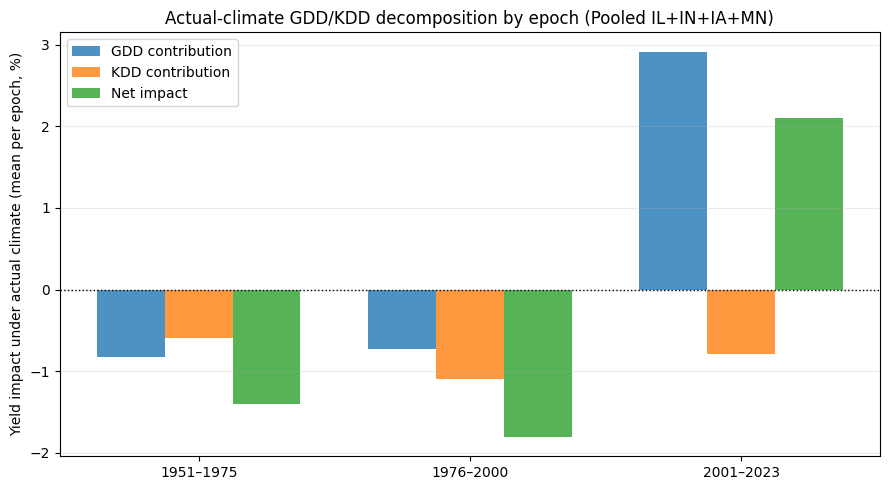

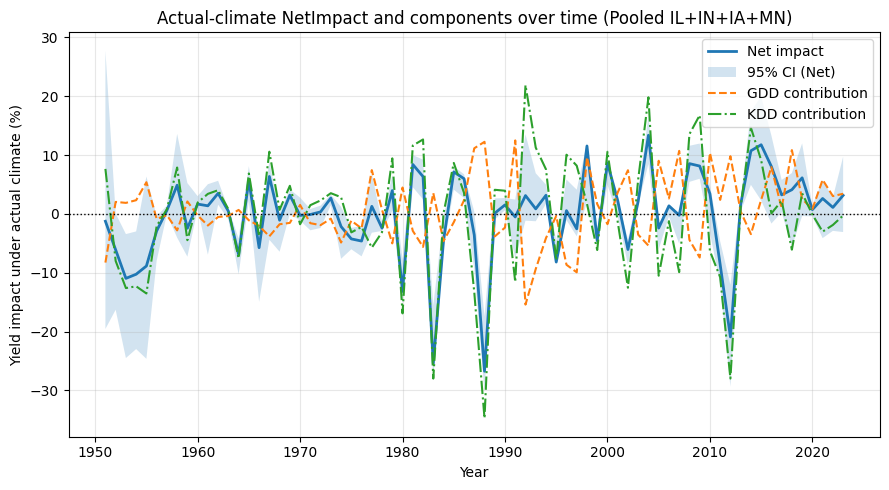

In [42]:
# ============================================================
# Step 4 – Run NetImpact decomposition under actual climate
# ============================================================

# 1. Load regional anomalies (mean over states, unweighted here)
state_year_anoms_step4, region_year_anoms_step4 = load_region_anomalies_from_master(
    master_csv_path=MASTER_CSV_PATH,
    states_keep=STATES_FOR_REGION,
    agg="mean",
    weight_col=None            # you can plug a production weight here later if you want
)

# 2. Compute yearly NetImpact and its GDD/KDD components
df_year_actual = compute_actual_climate_netimpact(
    proc_dict=proc_results,
    pooled_state_code=POOLED_STATE_CODE,
    region_year_anoms=region_year_anoms_step4,
    ci_low=2.5,
    ci_high=97.5
)

print("First few rows of yearly actual-climate NetImpact:")
display(df_year_actual.head())

# 3. Summarise by epoch (using the same 3 epochs as before)
df_epoch_actual = summarise_netimpact_by_epoch(
    df_year_impact=df_year_actual,
    epochs=EPOCHS_3
)

print("Epoch-level decomposition under actual climate:")
display(df_epoch_actual)

# 4. Plots: decomposition by epoch + full time series
plot_epoch_netimpact_decomposition(df_epoch_actual, title_suffix="(Pooled IL+IN+IA+MN)", percent=True)
plot_actual_netimpact_time_series(df_year_actual, title_suffix="(Pooled IL+IN+IA+MN)", percent=True)


### Step 5 – Functions: tail-focused hot-year penalty

In [44]:
# ============================================================
# Step 5: Tail-focused "hot-year penalty" (functions)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def summarize_hot_year_penalty(df_temp_impact,
                               epochs,
                               tail_q=0.80,
                               kdd_col="KDD_anom"):
    """
    Focus on the hottest years (top tail of KDD anomalies) and
    summarise their average GDD/KDD/Net impact by epoch.

    Inputs
    ------
    df_temp_impact : DataFrame
        Output from compute_climate_decomposition_yearly(..) for the
        pooled region. Needs columns:
          ['year', kdd_col, 'GDD_part_log', 'KDD_part_log', 'NetImpact_log'].
    epochs : list of (start_year, end_year)
        Epochs over which to summarise (e.g. EPOCHS_3).
    tail_q : float in (0,1)
        Quantile for defining "hot years". tail_q=0.80 means
        "years with KDD anomaly in the top 20%".
    kdd_col : str
        Column name for KDD anomalies.

    Returns
    -------
    df_hot : DataFrame with columns
      ['epoch_label','start_year','end_year',
       'n_hot_years','KDD_threshold',
       'mean_GDD_log','mean_KDD_log','mean_Net_log',
       'mean_GDD_pct','mean_KDD_pct','mean_Net_pct']
    """
    df = df_temp_impact.copy()

    if kdd_col not in df.columns:
        raise KeyError(f"Column '{kdd_col}' not found in df_temp_impact.")

    # Drop missing KDD anomalies if any
    df = df.dropna(subset=[kdd_col])

    # Threshold for "hot years" based on the *overall* KDD anomaly distribution
    kdd_thr = df[kdd_col].quantile(tail_q)

    df["is_hot"] = df[kdd_col] >= kdd_thr
    hot_df = df[df["is_hot"]].copy()

    print(f"[hot-years] Using overall {int(100*(1-tail_q))}% hottest years "
          f"based on KDD anomalies.")
    print(f"            Threshold KDD_anom ≥ {kdd_thr:.2f}")
    print(f"            Total hot years: {hot_df.shape[0]} out of {df.shape[0]}")

    rows = []
    for (y0, y1) in epochs:
        mask = (hot_df["year"] >= y0) & (hot_df["year"] <= y1)
        if not mask.any():
            print(f"[hot-years] No hot years in epoch {y0}–{y1}; skipping.")
            continue

        sub = hot_df.loc[mask]

        mG_log = sub["GDD_part_log"].mean()
        mK_log = sub["KDD_part_log"].mean()
        mN_log = sub["NetImpact_log"].mean()

        # Convert each mean log effect to % change
        mG_pct = 100.0 * (np.exp(mG_log) - 1.0)
        mK_pct = 100.0 * (np.exp(mK_log) - 1.0)
        mN_pct = 100.0 * (np.exp(mN_log) - 1.0)

        rows.append({
            "epoch_label": f"{y0}–{y1}",
            "start_year": int(y0),
            "end_year": int(y1),
            "n_hot_years": int(mask.sum()),
            "KDD_threshold": float(kdd_thr),
            "mean_GDD_log": mG_log,
            "mean_KDD_log": mK_log,
            "mean_Net_log": mN_log,
            "mean_GDD_pct": mG_pct,
            "mean_KDD_pct": mK_pct,
            "mean_Net_pct": mN_pct,
        })

    df_hot = pd.DataFrame(rows)
    return df_hot


def plot_hot_year_penalty(df_hot,
                          title_suffix="(Pooled IL+IN+IA+MN)",
                          tail_q=0.80):
    """
    Bar-plot of mean yield impact in 'hot years' only, by epoch.
    Uses percent effects for readability.
    """
    if df_hot.empty:
        print("[hot-years] No epochs with hot years to plot.")
        return

    epochs = df_hot["epoch_label"].tolist()
    x = np.arange(len(epochs))
    width = 0.28

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width, df_hot["mean_GDD_pct"], width,
           label="GDD contribution", alpha=0.8)
    ax.bar(x, df_hot["mean_KDD_pct"], width,
           label="KDD contribution", alpha=0.8)
    ax.bar(x + width, df_hot["mean_Net_pct"], width,
           label="Net impact", alpha=0.8)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(epochs)
    ax.set_ylabel("Yield impact in hot years (%)")
    top_share = int(round(100 * (1.0 - tail_q)))
    ax.set_title(f"Hot-year penalty (top {top_share}% KDD years) {title_suffix}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Annotate with the number of hot years per epoch
    for xi, n in zip(x, df_hot["n_hot_years"]):
        ax.text(xi, 0.02,
                f"n={n}", ha="center", va="bottom", fontsize=8,
                transform=ax.get_xaxis_transform())

    plt.tight_layout()
    plt.show()


### Step 5 – Calling the functions for your pooled panel

Combined NetImpact + anomalies (first rows):


,year,GDD_anom_x,KDD_anom_x,GDD_part_log,KDD_part_log,NetImpact_log,Net_lo_log,Net_hi_log,GDD_anom_y,KDD_anom_y
0,1951,-178.126621,-52.206615,-0.086234,0.073761,-0.012472,-0.217458,0.244837,-178.126621,-52.206615
1,1952,50.735760,61.109761,0.020274,-0.083234,-0.062960,-0.177768,0.000892,50.735760,61.109761
2,1953,54.548043,100.751534,0.018664,-0.134600,-0.115936,-0.280874,-0.034800,54.548043,100.751534
3,1954,76.245438,98.144524,0.023124,-0.131211,-0.108087,-0.260841,-0.030142,76.245438,98.144524
4,1955,192.951788,107.550202,0.052489,-0.145131,-0.092642,-0.282567,0.061598,192.951788,107.550202


[hot-years] Using overall 19% hottest years based on KDD anomalies.
            Threshold KDD_anom ≥ 39.89
            Total hot years: 15 out of 73


,epoch_label,start_year,end_year,n_hot_years,KDD_threshold,mean_GDD_log,mean_KDD_log,mean_Net_log,mean_GDD_pct,mean_KDD_pct,mean_Net_pct
0,1951–1975,1951,1975,5,39.889006,0.024274,-0.114533,-0.090259,2.457147,-10.821793,-8.630553
1,1976–2000,1976,2000,5,39.889006,0.083604,-0.241000,-0.157397,8.719780,-21.415852,-14.563487
2,2001–2023,2001,2023,5,39.889006,0.075458,-0.158109,-0.082651,7.837743,-14.624300,-7.932772


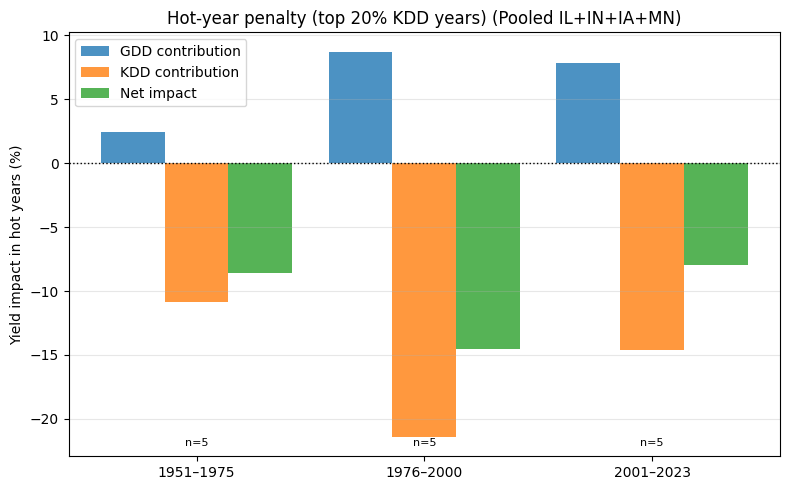

In [46]:
# ============================================================
# Step 5: Run tail-focused hot-year penalty for pooled panel
# ============================================================

# Make sure Step 4 has been run so that:
# - df_year_actual           exists
# - region_year_anoms_step4  exists
# - EPOCHS_3                 is defined

TAIL_Q = 0.80   # use top 20% hottest KDD years

# 1) Combine actual NetImpact (df_year_actual) with regional anomalies
#    so we have year, NetImpact, and KDD_anom all in one DataFrame.
df_temp_impact_pooled = (
    df_year_actual
    .merge(
        region_year_anoms_step4.reset_index()[["year", "GDD_anom", "KDD_anom"]],
        on="year",
        how="left"
    )
)

print("Combined NetImpact + anomalies (first rows):")
display(df_temp_impact_pooled.head())

# 2) Summarise hot-year penalty by epoch
df_hot_epochs = summarize_hot_year_penalty(
    df_temp_impact=df_temp_impact_pooled,
    epochs=EPOCHS_3,
    tail_q=TAIL_Q,
    kdd_col="KDD_anom_x"   # <--- change here
)

display(df_hot_epochs)

# 3) Plot
plot_hot_year_penalty(
    df_hot=df_hot_epochs,
    title_suffix="(Pooled IL+IN+IA+MN)",
    tail_q=TAIL_Q
)


### Step 6 - Yu-like analysis functions

In [72]:
# ============================================================
# Step 6 – Yu-style decomposition: climate vs sensitivity
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_epoch_mean_anoms(region_year_anoms,
                             epochs,
                             gdd_col="GDD_anom",
                             kdd_col="KDD_anom"):
    """
    Compute mean regional GDD/KDD anomalies for each epoch.

    Inputs
    ------
    region_year_anoms : DataFrame with yearly GDD/KDD anomalies.
                        'year' can be either a column or the index.
    epochs            : list of (start_year, end_year) tuples
    gdd_col, kdd_col  : column names for GDD/KDD anomalies

    Returns
    -------
    DataFrame with:
      ['epoch_label','start_year','end_year',
       'GDD_anom_mean','KDD_anom_mean']
    """
    df = region_year_anoms.copy()

    # --- robust handling of year ---
    if "year" in df.columns:
        # normal case
        df["year"] = df["year"].astype(int)
    else:
        # assume index encodes years
        df = df.reset_index()
        # if the index had a name use that, otherwise call it 'year'
        if "year" not in df.columns:
            df = df.rename(columns={df.columns[0]: "year"})
        df["year"] = df["year"].astype(int)

    rows = []
    for (y0, y1) in epochs:
        y0, y1 = int(y0), int(y1)
        mask = (df["year"] >= y0) & (df["year"] <= y1)
        if not mask.any():
            print(f"[epoch-anoms] Warning: no data in {y0}–{y1}. Skipping.")
            continue

        g_mean = df.loc[mask, gdd_col].astype(float).mean()
        k_mean = df.loc[mask, kdd_col].astype(float).mean()

        rows.append({
            "epoch_label": f"{y0}–{y1}",
            "start_year": y0,
            "end_year": y1,
            "GDD_anom_mean": g_mean,
            "KDD_anom_mean": k_mean
        })

    return pd.DataFrame(rows)



def yu_climate_sensitivity_decomposition(df_epoch_betas,
                                         df_epoch_anoms):
    """
    Yu-style decomposition between successive epochs.

    For each pair of epochs (old -> new):

      Let beta_old, beta_new be [β_GDD, β_KDD]
      Let X_old, X_new be [ΔGDD_mean, ΔKDD_mean]

      Y_old_log = beta_old · X_old
      Y_new_log = beta_new · X_new

      Climate effect:
        ΔY_climate_log = beta_old · (X_new - X_old)

      Sensitivity effect:
        ΔY_sens_log    = (beta_new - beta_old) · X_new

      Total change:
        ΔY_total_log   = Y_new_log - Y_old_log

      Residual (should be ~0):
        ΔY_resid_log   = ΔY_total_log - ΔY_climate_log - ΔY_sens_log

    Percent versions use 100*(exp(ΔY) - 1).

    Inputs
    ------
    df_epoch_betas : from compute_epoch_avg_betas
                     (must have ['epoch_label','start_year','beta_GDD','beta_KDD'])
    df_epoch_anoms : from compute_epoch_mean_anoms
                     (must have ['epoch_label','start_year','GDD_anom_mean','KDD_anom_mean'])

    Returns
    -------
    DataFrame with one row per transition (epoch_i -> epoch_{i+1}):
      ['from_epoch','to_epoch',
       'from_start','to_start',
       'Y_old_log','Y_new_log',
       'dY_total_log','dY_climate_log','dY_sens_log','dY_resid_log',
       'dY_total_pct','dY_climate_pct','dY_sens_pct','dY_resid_pct']
    """
    # Merge betas and anomalies by epoch label (or start_year to be safe)
    df_b = df_epoch_betas.copy()
    df_a = df_epoch_anoms.copy()

    # Use start_year as the key to avoid label-mismatch issues
    merged = pd.merge(
        df_b,
        df_a[["start_year", "GDD_anom_mean", "KDD_anom_mean"]],
        on="start_year",
        how="inner",
        suffixes=("_beta", "_anom")
    ).sort_values("start_year").reset_index(drop=True)

    rows = []
    for i in range(len(merged) - 1):
        old = merged.iloc[i]
        new = merged.iloc[i + 1]

        beta_old = np.array([old["beta_GDD"], old["beta_KDD"]], dtype=float)
        beta_new = np.array([new["beta_GDD"], new["beta_KDD"]], dtype=float)

        X_old = np.array([old["GDD_anom_mean"], old["KDD_anom_mean"]], dtype=float)
        X_new = np.array([new["GDD_anom_mean"], new["KDD_anom_mean"]], dtype=float)

        # Expected log-yield under each epoch’s climate & sensitivity
        Y_old_log = float(beta_old @ X_old)
        Y_new_log = float(beta_new @ X_new)

        # Decomposition
        dY_total_log    = Y_new_log - Y_old_log
        dY_climate_log  = float(beta_old @ (X_new - X_old))
        dY_sens_log     = float((beta_new - beta_old) @ X_new)
        dY_resid_log    = dY_total_log - dY_climate_log - dY_sens_log

        # Convert to percent effects
        dY_total_pct   = 100.0 * (np.exp(dY_total_log)  - 1.0)
        dY_climate_pct = 100.0 * (np.exp(dY_climate_log) - 1.0)
        dY_sens_pct    = 100.0 * (np.exp(dY_sens_log)    - 1.0)
        dY_resid_pct   = 100.0 * (np.exp(dY_resid_log)   - 1.0)

        rows.append({
            "from_epoch": old["epoch_label"],
            "to_epoch":   new["epoch_label"],
            "from_start": int(old["start_year"]),
            "to_start":   int(new["start_year"]),
            "Y_old_log": Y_old_log,
            "Y_new_log": Y_new_log,
            "dY_total_log": dY_total_log,
            "dY_climate_log": dY_climate_log,
            "dY_sens_log": dY_sens_log,
            "dY_resid_log": dY_resid_log,
            "dY_total_pct": dY_total_pct,
            "dY_climate_pct": dY_climate_pct,
            "dY_sens_pct": dY_sens_pct,
            "dY_resid_pct": dY_resid_pct
        })

    return pd.DataFrame(rows)


def plot_yu_decomposition(df_yu, title_suffix="(Pooled IL+IN+IA+MN)"):
    """
    Simple bar plot of climate vs sensitivity contributions (in %) for each
    transition between epochs.
    """
    pairs = [f"{r['from_epoch']} → {r['to_epoch']}" for _, r in df_yu.iterrows()]
    x = np.arange(len(pairs))
    width = 0.3

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(x - width, df_yu["d_climate_pct"], width,
           label="Climate effect", alpha=0.8)
    ax.bar(x,         df_yu["d_sens_pct"],    width,
           label="Sensitivity effect", alpha=0.8)
    ax.bar(x + width, df_yu["d_total_pct"],   width,
           label="Total change", alpha=0.5)

    ax.axhline(0.0, color="k", linestyle=":", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs, rotation=0)
    ax.set_ylabel("Change in expected yield (%)")
    ax.set_title(f"Yu-style decomposition: climate vs sensitivity {title_suffix}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Small wrapper to rename columns for plotting convenience
def prepare_yu_for_plot(df_yu_raw):
    df = df_yu_raw.copy()
    df["d_climate_pct"] = df["dY_climate_pct"]
    df["d_sens_pct"]    = df["dY_sens_pct"]
    df["d_total_pct"]   = df["dY_total_pct"]
    return df


,epoch_label,start_year,end_year,GDD_anom_mean,KDD_anom_mean
0,1951–1975,1951,1975,-35.940228,5.953267
1,1976–2000,1976,2000,-9.891645,5.198127
2,2001–2023,2001,2023,56.482268,4.052551


,from_epoch,to_epoch,from_start,to_start,Y_old_log,Y_new_log,dY_total_log,dY_climate_log,dY_sens_log,dY_resid_log,dY_total_pct,dY_climate_pct,dY_sens_pct,dY_resid_pct
0,1951–1975,1976–2000,1951,1976,-0.018093,-0.018143,-0.000050,0.007471,-0.007522,2.602085e-18,-0.005010,0.74994,-0.749330,0.0
1,1976–2000,2001–2023,1976,2001,-0.018143,0.021444,0.039587,0.040603,-0.001016,-6.505213e-18,4.038094,4.14390,-0.101596,0.0


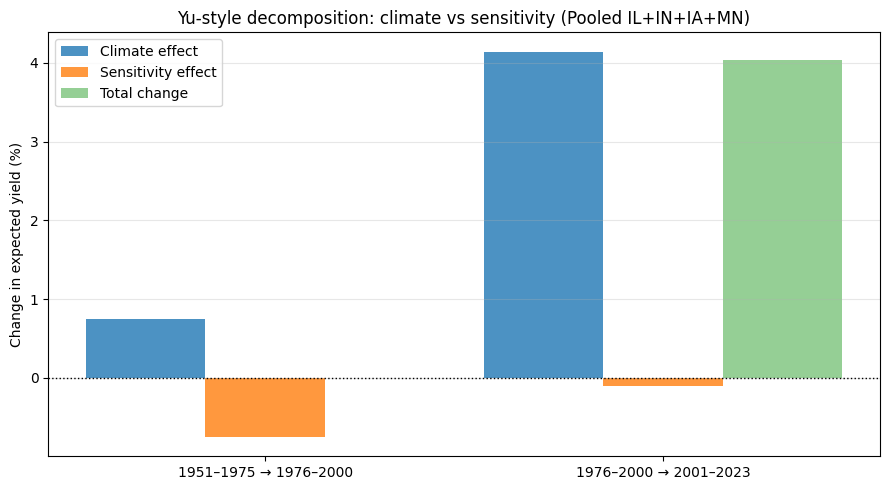

In [74]:
# ============================================================
# Step 6: Run Yu-style climate vs sensitivity decomposition
# ============================================================

# We assume you already have:
# - df_epoch_betas         (from Step 1, pooled panel)
# - region_year_anoms_step4 (from Step 4: load_region_anomalies_from_master)
# - EPOCHS_3               ([(1951,1975), (1976,2000), (2001,2023)])

# 1. Mean anomalies per epoch (pooled IL+IN+IA+MN)
df_epoch_anoms = compute_epoch_mean_anoms(
    region_year_anoms=region_year_anoms_step4,
    epochs=EPOCHS_3,
    gdd_col="GDD_anom",
    kdd_col="KDD_anom"
)

display(df_epoch_anoms)

df_yu_raw = yu_climate_sensitivity_decomposition(
    df_epoch_betas=df_epoch_betas,
    df_epoch_anoms=df_epoch_anoms
)

display(df_yu_raw)

df_yu_plot = prepare_yu_for_plot(df_yu_raw)
plot_yu_decomposition(df_yu_plot, title_suffix="(Pooled IL+IN+IA+MN)")



## Simple metrics

In [77]:
# ============================================================
# Step 7 – Simple interpretation metrics per epoch
# ============================================================

import numpy as np
import pandas as pd

def compute_epoch_interpretation_metrics(df_epoch_betas):
    """
    From epoch-average betas, compute:
      1) Below-threshold slope (benefit rate):   m_<29 = beta_GDD
      2) Above-threshold slope (heat penalty):   m_>29 = beta_KDD
      3) Penalty of a 35°C day vs 29°C day:      6 * beta_KDD
      4) Gain of a 25°C day vs 10°C day:         15 * beta_GDD

    All first in log units, then converted to percent:
        pct = 100 * (exp(log) - 1)

    Parameters
    ----------
    df_epoch_betas : DataFrame
        Must contain at least:
          - 'epoch_label'
          - 'beta_GDD'
          - 'beta_KDD'

    Returns
    -------
    df_metrics : DataFrame with columns:
        ['epoch_label',
         'm_below_log','m_below_pct',
         'm_above_log','m_above_pct',
         'penalty35_log','penalty35_pct',
         'gain25_log','gain25_pct']
    """
    df = df_epoch_betas.copy()

    # 1) Below-threshold slope (benefit rate), per +1 GDD degree (T < 29°C)
    df["m_below_log"] = df["beta_GDD"]
    df["m_below_pct"] = 100.0 * (np.exp(df["m_below_log"]) - 1.0)

    # 2) Above-threshold slope (heat penalty), per +1 KDD degree (T > 29°C)
    df["m_above_log"] = df["beta_KDD"]
    df["m_above_pct"] = 100.0 * (np.exp(df["m_above_log"]) - 1.0)

    # 3) Penalty of a 35°C vs 29°C day: 6 KDD degrees
    df["penalty35_log"] = 6.0 * df["beta_KDD"]
    df["penalty35_pct"] = 100.0 * (np.exp(df["penalty35_log"]) - 1.0)

    # 4) Gain of a 25°C vs 10°C day: 15 GDD degrees
    df["gain25_log"] = 15.0 * df["beta_GDD"]
    df["gain25_pct"] = 100.0 * (np.exp(df["gain25_log"]) - 1.0)

    # Keep only the relevant columns, nicely ordered
    cols = [
        "epoch_label",
        "m_below_log", "m_below_pct",
        "m_above_log", "m_above_pct",
        "penalty35_log", "penalty35_pct",
        "gain25_log", "gain25_pct"
    ]
    return df[cols]


In [79]:
# ============================================================
# Step 7 – Run interpretation metrics for the 3 epochs
# ============================================================

# df_epoch_betas should already exist from Step 1
# (columns: 'epoch_label','beta_GDD','beta_KDD', ...)

df_epoch_metrics = compute_epoch_interpretation_metrics(df_epoch_betas)

# Optional: round for nicer display
df_epoch_metrics_rounded = df_epoch_metrics.copy()
for c in df_epoch_metrics_rounded.columns:
    if c != "epoch_label":
        df_epoch_metrics_rounded[c] = df_epoch_metrics_rounded[c].round(4)

display(df_epoch_metrics_rounded)


,epoch_label,m_below_log,m_below_pct,m_above_log,m_above_pct,penalty35_log,penalty35_pct,gain25_log,gain25_pct
0,1951–1975,0.0002,0.0241,-0.0016,-0.1584,-0.0095,-0.9465,0.0036,0.3620
1,1976–2000,0.0006,0.0570,-0.0024,-0.2402,-0.0144,-1.4328,0.0086,0.8590
2,2001–2023,0.0005,0.0529,-0.0021,-0.2076,-0.0125,-1.2392,0.0079,0.7963
